# Fourth-Estimation Results: Visualization

Visualizes parameter-estimation results saved as CSVs in `results/fourth_estimation/`.
This notebook is pure load-from-CSV + plot -- it does NOT import the estimator or re-run any fit.

IMPORTANT: The fourth estimation fits only the FREE parameters (15/37 -- Ks_fbp_4
was moved from free to fixed relative to the third estimation, as an exploratory
check of whether that helps or is unnecessary; see fourth_estimation.ipynb), so
`correlation.csv` and `confidence_intervals.csv` cover only that subset. The
sensitivity heatmap stays over all 37 params (sensitivity CSVs are 18x37).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl
from matplotlib.patches import Rectangle as MplRect
from matplotlib.transforms import blended_transform_factory
from pathlib import Path

RESULTS_DIR = Path('results/fourth_estimation')
FIG_DIR = RESULTS_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

ci_df = pd.read_csv(RESULTS_DIR / 'confidence_intervals.csv', index_col=0)
corr_df = pd.read_csv(RESULTS_DIR / 'correlation.csv', index_col=0)
cov_df = pd.read_csv(RESULTS_DIR / 'covariance.csv', index_col=0)
struct_df = pd.read_csv(RESULTS_DIR / 'structural_report_per_parameter.csv', index_col=0)
ident_df = pd.read_csv(RESULTS_DIR / 'structural_report_identifiability.csv', index_col=0)

# Stack per-condition sensitivity CSVs into G_stack of shape (n_cond, 18, 37)
# Sensitivity is over ALL 37 params even though the fit covered only free params.
sens_files = sorted((RESULTS_DIR / 'sensitivity').glob('*.csv'))
G_list = []
row_kind = None
row_name = None
param_cols = None
cond_names = []

for fp in sens_files:
    df = pd.read_csv(fp)
    if row_kind is None:
        row_kind = df['kind'].tolist()
        row_name = df['name'].tolist()
        param_cols = [c for c in df.columns if c not in ('kind', 'name')]
    else:
        assert df['kind'].tolist() == row_kind, 'row_kind mismatch across conditions'
        assert df['name'].tolist() == row_name, 'row_name mismatch across conditions'
    G_list.append(df[param_cols].values.astype(float))
    cond_names.append(fp.stem)

G_stack = np.stack(G_list, axis=0)  # shape: (n_cond, 18, 37)
print(f'G_stack shape: {G_stack.shape}, conditions: {len(cond_names)}')

# PARAMS is the FREE-param subset present in correlation/CI CSVs (not all 37).
PARAMS = list(ci_df.index)
assert PARAMS == list(corr_df.columns), 'PARAMS order mismatch between ci_df and corr_df'
print(f'PARAMS (free params, {len(PARAMS)}): {PARAMS}')
print(f'Sensitivity param_cols ({len(param_cols)} total): covers all 37 params')

G_stack shape: (22, 18, 37), conditions: 22
PARAMS (free params, 15): ['v_max_1', 'Ka2_1', 'Ka3_1', 'K_g6p_1', 'Ks_g6p_pgi', 'kcat_f_2', 'kcat_f_3', 'kcat_f_4', 'kcat_f_5', 'kcat_f_6', 'kcat_f_7', 'kcat_f_8', 'Ks_3pg_8', 'kcat_f_9', 'Ks_2pg_9']
Sensitivity param_cols (37 total): covers all 37 params


In [2]:
ci_df

,theta,std_err,ci_low,ci_high,cv_percent
v_max_1,74.298880,2.577694e+09,-5.052280e+09,5.052280e+09,3.469357e+09
Ka2_1,0.060369,2.278925e+06,-4.466693e+06,4.466694e+06,3.774999e+09
Ka3_1,5.190128,1.916935e+08,-3.757192e+08,3.757192e+08,3.693425e+09
K_g6p_1,10.695771,7.754393e+08,-1.519861e+09,1.519861e+09,7.249962e+09
Ks_g6p_pgi,1.370224,8.546324e+00,-1.538057e+01,1.812102e+01,6.237174e+02
kcat_f_2,521.376460,2.768774e+03,-4.905421e+03,5.948174e+03,5.310509e+02
kcat_f_3,693.684107,6.334747e+04,-1.234674e+05,1.248547e+05,9.132035e+03
kcat_f_4,3.672335,5.803561e-01,2.534837e+00,4.809833e+00,1.580346e+01
kcat_f_5,2911.580449,4.643138e+05,-9.071434e+05,9.129666e+05,1.594714e+04
kcat_f_6,15.527731,1.610996e+06,-3.157537e+06,3.157568e+06,1.037496e+07


## Verification: tight CI vs big covariance entry is not a bug

The forest plot shows `v_max_1` with a tight confidence interval while
`covariance.csv` has large entries in the `v_max_1` row. The cell below confirms
these are consistent: each CI standard error equals the square root of the
covariance *diagonal*, and the large numbers live *off* the diagonal (couplings
to non-identifiable parameters whose own variances are enormous). The forest plot
uses only the diagonal, so it is correct -- and below it is rebuilt from the
well-conditioned identifiable-only covariance so the scale is readable.

In [3]:
# VERIFICATION: CI std_err equals sqrt of covariance diagonal for the free params.
_diag = np.sqrt(np.clip(np.diag(cov_df.to_numpy()), 0.0, None))
assert np.allclose(_diag, ci_df['std_err'].to_numpy(), rtol=1e-6, atol=1e-9), \
    'std_err != sqrt(diag(cov)) -- this WOULD be a bug'
print('OK: ci_df.std_err == sqrt(diag(covariance)) for all %d free params.' % len(PARAMS))

OK: ci_df.std_err == sqrt(diag(covariance)) for all 15 free params.


In [4]:
# Shared style block -- adapted from sensitivity_analysis.ipynb
# IMPORTANT: fourth estimation has free params only in corr/CI CSVs (15 params).
# _perm is built from ACTUAL columns present in the loaded CSVs, not all 37.
# _perm_all covers all 37 for the sensitivity heatmap.

import sys, os; sys.path.insert(0, os.path.join(os.path.abspath('.'), 'src'))
from utils import REACTION_GROUPS as reaction_groups, PARAM_LATEX_LABELS as _param_labels_orig, TYPE_COLOR, KCAT0 as _KCAT0, PTS0 as _PTS0

def _t0(i): return 'pts' if i in _PTS0 else ('kcat' if i in _KCAT0 else 'km')
_rank = {'kcat': 0, 'km': 1, 'pts': 0}

# Full perm over all 37 params (for sensitivity heatmap x-axis)
_perm_all = []
for _nm, _is, _ie, _c in reaction_groups:
    _perm_all += sorted(range(_is, _ie + 1), key=lambda i: (_rank[_t0(i)], i))

# Derive _perm restricted to free params actually in the CSVs.
# Walk reaction_groups in order, keep only indices whose param_cols name is in PARAMS.
_perm = []
for _nm, _is, _ie, _c in reaction_groups:
    for i in sorted(range(_is, _ie + 1), key=lambda i: (_rank[_t0(i)], i)):
        if param_cols[i] in PARAMS:
            _perm.append(i)

param_labels_p = [_param_labels_orig[i] for i in _perm]
KCAT_IDX = {p for p, o in enumerate(_perm) if o in _KCAT0}
PTS_IDX  = {p for p, o in enumerate(_perm) if o in _PTS0}

# For sensitivity heatmap
param_labels_all = [_param_labels_orig[i] for i in _perm_all]
KCAT_IDX_ALL = {p for p, o in enumerate(_perm_all) if o in _KCAT0}
PTS_IDX_ALL  = {p for p, o in enumerate(_perm_all) if o in _PTS0}

def _type_color(i):
    if i in PTS_IDX:  return TYPE_COLOR['pts']
    if i in KCAT_IDX: return TYPE_COLOR['kcat']
    return TYPE_COLOR['km']

def _type_color_all(i):
    if i in PTS_IDX_ALL:  return TYPE_COLOR['pts']
    if i in KCAT_IDX_ALL: return TYPE_COLOR['kcat']
    return TYPE_COLOR['km']

def styled_matrix_heatmap(M_permuted, vmin, vmax, cbar_label, savepath,
                          cmap_name='RdBu_r', extend='neither',
                          annotate=False, annot_fs=5.0):
    """
    Render a pre-permuted square matrix (free params) with reference styling.
    """
    _rc_save = {k: mpl.rcParams[k] for k in (
        'font.family', 'font.size', 'axes.linewidth', 'mathtext.fontset')}
    mpl.rcParams.update({
        'font.family':     'sans-serif',
        'font.size':        9,
        'axes.linewidth':   0.6,
        'mathtext.fontset': 'dejavusans',
    })

    cmap = mpl.colormaps[cmap_name].copy()
    cmap.set_bad('#e9e9ec')

    GAP      = 0.35
    STRIP    = 1.4
    TICK_FS  = 11
    STRIP_FS = 9

    n = M_permuted.shape[0]
    fig, ax = plt.subplots(figsize=(10.5, 10.5), dpi=200)
    im = ax.imshow(M_permuted, cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='none', aspect='equal')

    ax.set_xlim(-0.5, n - 0.5 + GAP + STRIP)
    ax.set_ylim(n - 0.5, -0.5 - GAP - STRIP)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(param_labels_p, rotation=90, fontsize=TICK_FS, ha='center')
    ax.set_yticklabels(param_labels_p, fontsize=TICK_FS)

    for i, t in enumerate(ax.get_xticklabels()):
        t.set_color(_type_color(i)); t.set_fontweight('semibold')
    for i, t in enumerate(ax.get_yticklabels()):
        t.set_color(_type_color(i)); t.set_fontweight('semibold')
    ax.tick_params(length=2, width=0.5, pad=2)

    for k in np.arange(-0.5, n, 1):
        ax.plot([-0.5, n - 0.5], [k, k], color='white', lw=0.5, zorder=1)
        ax.plot([k, k], [-0.5, n - 0.5], color='white', lw=0.5, zorder=1)

    # Draw reaction group separators and strips based on params present
    seen_rxns = {}
    for p_pos, orig_i in enumerate(_perm):
        for name, i_s, i_e, col in reaction_groups:
            if i_s <= orig_i <= i_e:
                if name not in seen_rxns:
                    seen_rxns[name] = [p_pos, p_pos, col]
                else:
                    seen_rxns[name][1] = p_pos
    for name, (k0, k1, col) in seen_rxns.items():
        if k0 > 0:
            ax.plot([k0 - 0.5, k0 - 0.5], [-0.5, n - 0.5], color='#2b2b2b', lw=1.1, zorder=3)
            ax.plot([-0.5, n - 0.5], [k0 - 0.5, k0 - 0.5], color='#2b2b2b', lw=1.1, zorder=3)
        ax.add_patch(MplRect((k0 - 0.5, k0 - 0.5), k1 - k0 + 1, k1 - k0 + 1,
                             fill=False, edgecolor=col, lw=1.6, zorder=5))
    ax.add_patch(MplRect((-0.5, -0.5), n, n, fill=False, edgecolor='#2b2b2b', lw=1.1, zorder=6))

    top_y   = -0.5 - GAP - STRIP
    right_x = n - 0.5 + GAP
    for name, (k0, k1, col) in seen_rxns.items():
        w = k1 - k0 + 1
        ax.add_patch(MplRect((k0 - 0.5, top_y), w, STRIP,
                             facecolor=col, edgecolor='white', lw=1.0, zorder=4))
        ax.text((k0 + k1) / 2, top_y + STRIP / 2, name, ha='center', va='center',
                fontsize=STRIP_FS, fontweight='bold', color='white', zorder=5)
        ax.add_patch(MplRect((right_x, k0 - 0.5), STRIP, w,
                             facecolor=col, edgecolor='white', lw=1.0, zorder=4))
        ax.text(right_x + STRIP / 2, (k0 + k1) / 2, name, ha='center', va='center',
                fontsize=STRIP_FS, fontweight='bold', color='white', rotation=270, zorder=5)

    for s in ('top', 'right', 'bottom', 'left'):
        ax.spines[s].set_visible(False)

    if annotate:
        for _r in range(n):
            for _c in range(n):
                _v = M_permuted[_r, _c]
                if not np.isfinite(_v):
                    continue
                _rr, _gg, _bb, _ = im.cmap(im.norm(_v))
                _lum = 0.299 * _rr + 0.587 * _gg + 0.114 * _bb
                ax.text(_c, _r, '%.2f' % _v, ha='center', va='center',
                        fontsize=annot_fs,
                        color='white' if _lum < 0.55 else 'black', zorder=7)

    cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03, shrink=0.6, extend=extend)
    cbar.set_label(cbar_label, fontsize=11, labelpad=4)
    cbar.ax.tick_params(labelsize=9, length=3, width=0.5)
    cbar.outline.set_linewidth(0.6)

    fig.savefig(savepath, dpi=300, bbox_inches='tight')
    fig.savefig(savepath.with_suffix('.jpg'), dpi=600, bbox_inches='tight', facecolor='white')
    plt.show()

    mpl.rcParams.update(_rc_save)

print('Shared style block loaded.')
print(f'_perm length (free params): {len(_perm)}')
print(f'_perm_all length (all 37): {len(_perm_all)}')
print(f'KCAT_IDX positions: {sorted(KCAT_IDX)}')
print(f'PTS_IDX  positions: {sorted(PTS_IDX)}')

Shared style block loaded.
_perm length (free params): 15
_perm_all length (all 37): 37
KCAT_IDX positions: [4, 6, 7, 8, 9, 10, 11, 13]
PTS_IDX  positions: [0, 1, 2, 3]


## Sensitivity Analysis

Mean **relative** sensitivity $|d\ln y / d\ln\theta| = |(dy/d\theta)\,\theta_j / y_i|$ averaged over all conditions, split by concentration block (rows 0-8) and flux block (rows 9-17) with separate (log) color scales.

Relative sensitivity rescales the saved absolute sensitivities by the fitted parameter value $\theta_j$ and the predicted output magnitude $y_i$, giving a dimensionless, comparable-across-outputs measure. All 9 balanced metabolite concentrations have finite model predictions (including previously-unmeasured C_g3p, C_pgp, C_2pg), so all rows are normalized and appear in the heatmap. Individual cells whose relative sensitivity falls below the magnitude threshold are still rendered grey.

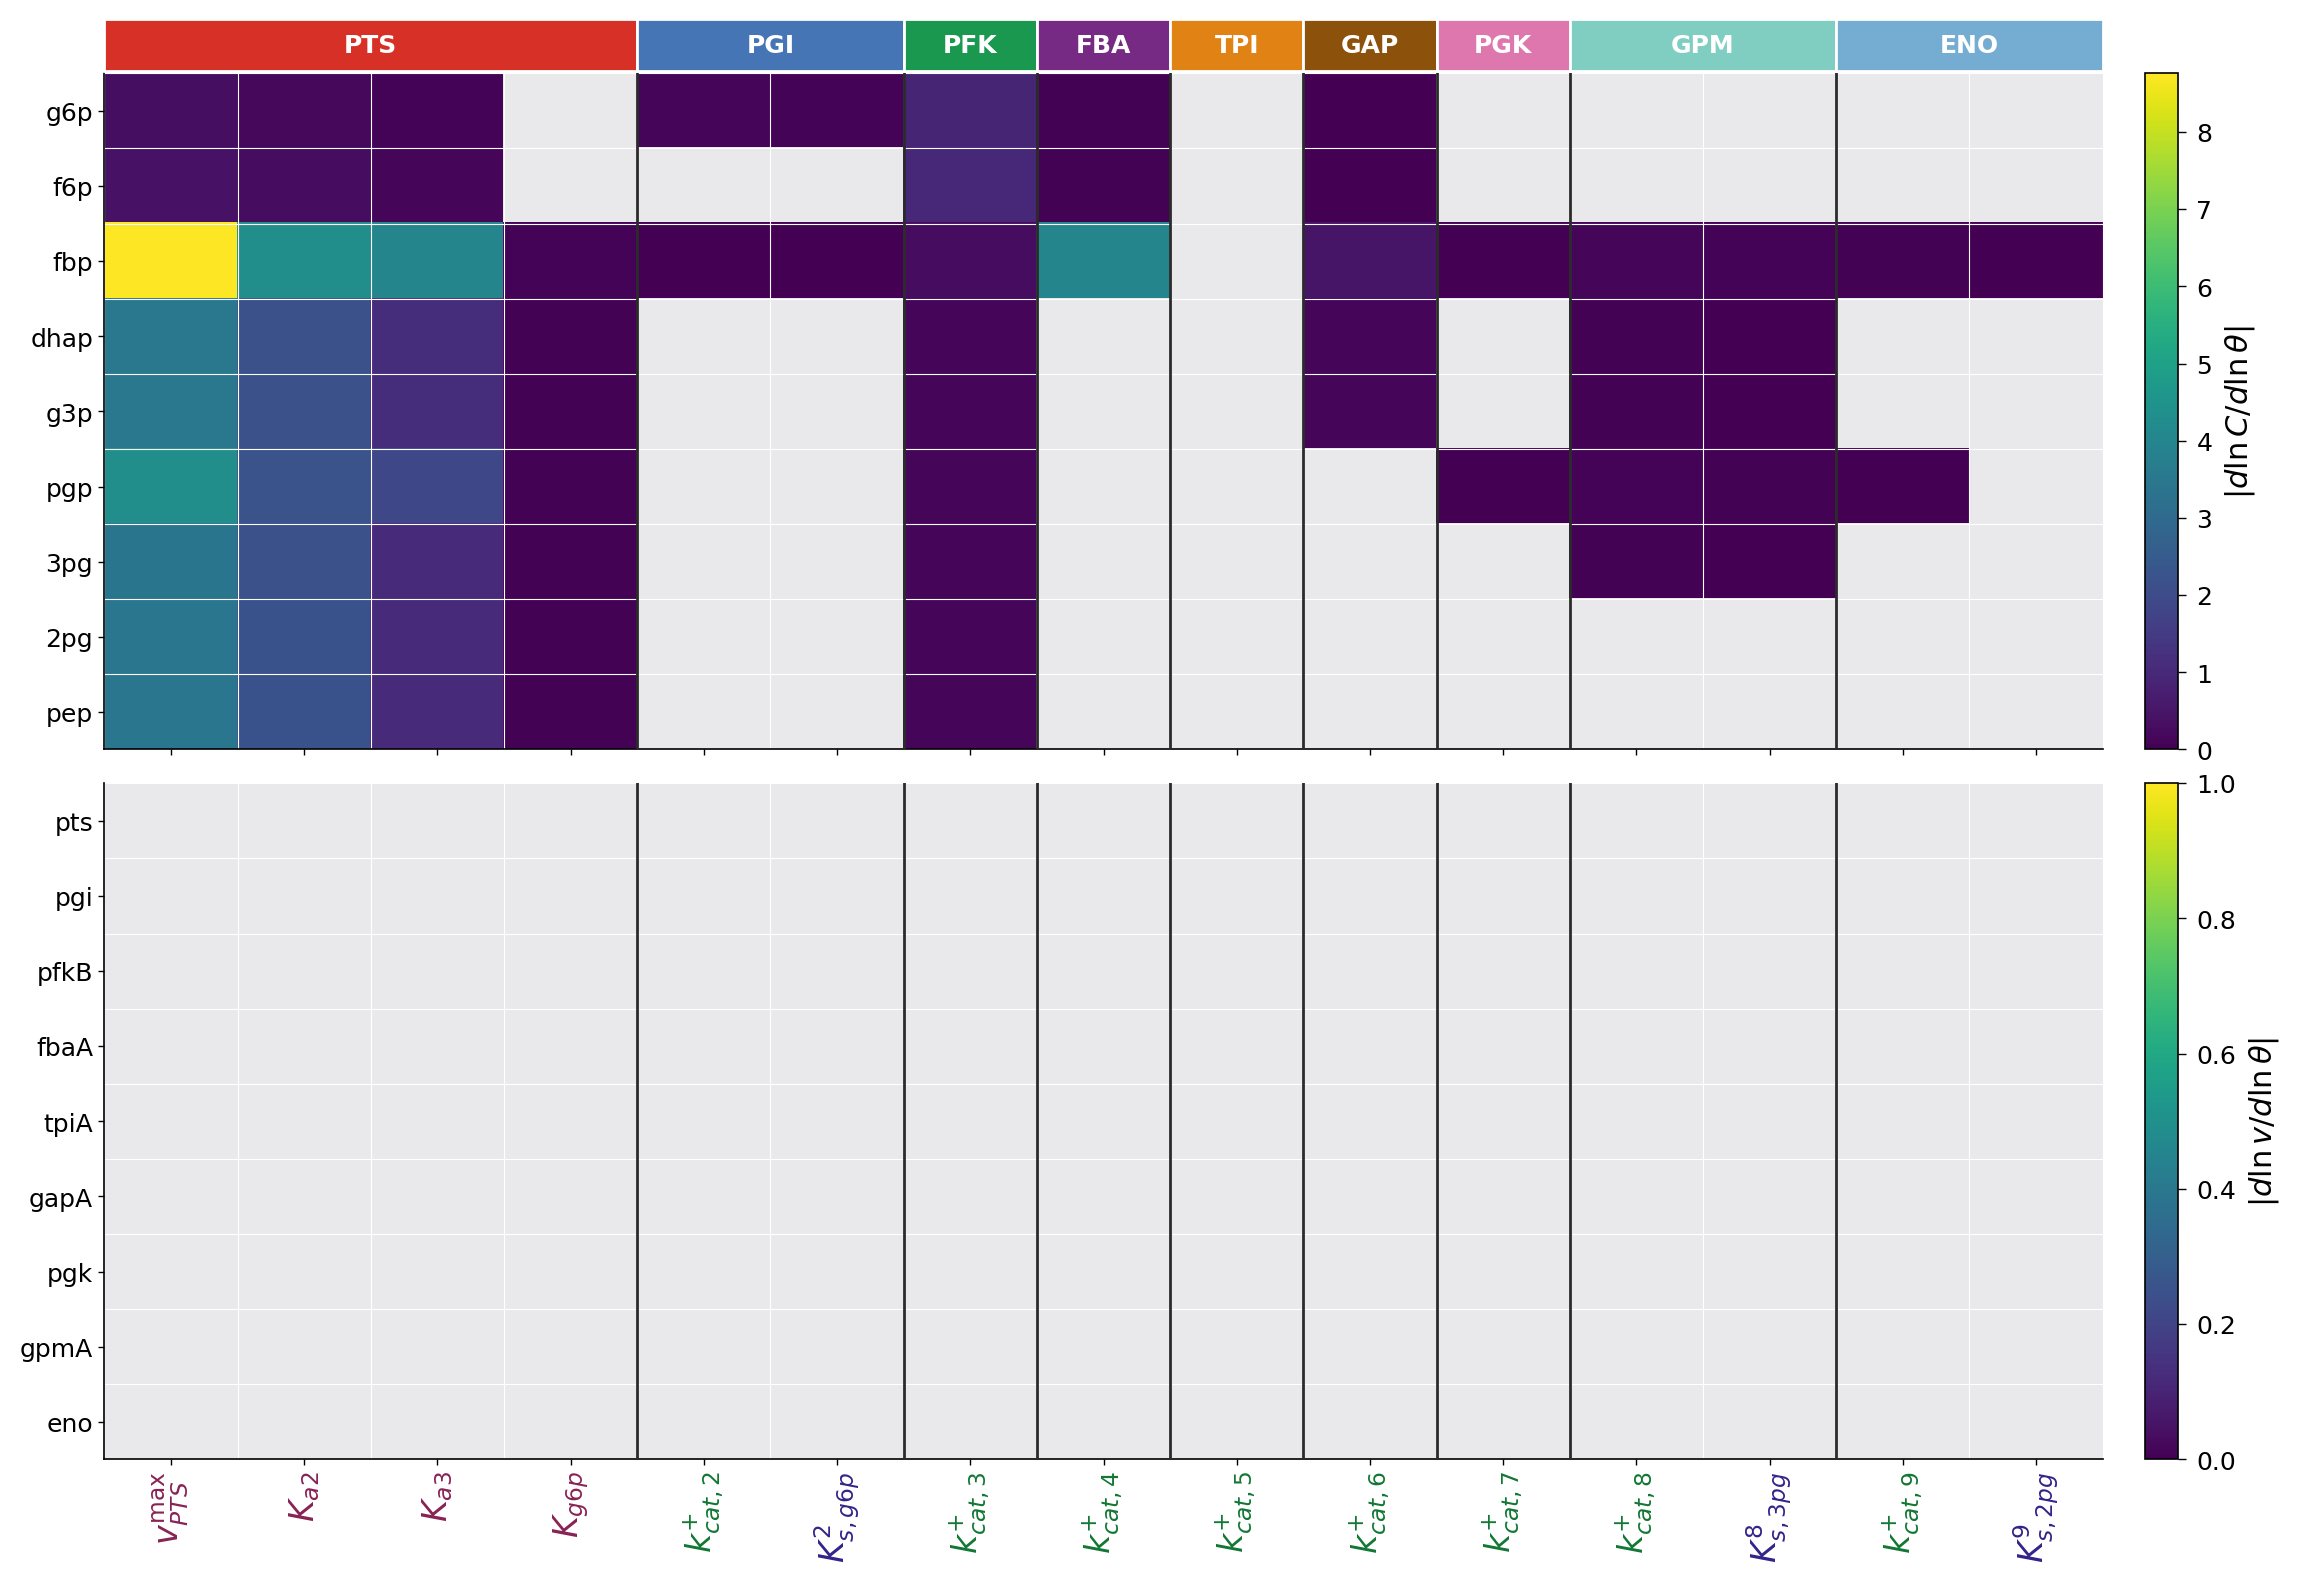

Saved: sensitivity_rel_mean.pdf
Thresholds: conc >= 0.01, flux >= 0.01
Log scale: conc=False, flux=False
Cells shown: conc 70/135, flux 0/135


In [5]:
# Sensitivity heatmap: RELATIVE mean over conditions, split concentration/flux scales
import warnings
from matplotlib.colors import LogNorm

# all 22 conditions; all 9 concentration rows now have finite model predictions.
theta_fit = pd.read_csv(RESULTS_DIR / 'theta_fitted.csv', index_col=0)['value']
pred_fit = pd.read_csv(RESULTS_DIR / 'predictions_fitted.csv', index_col=0)

theta_vec = theta_fit.reindex(param_cols).to_numpy(dtype=float)            # (37,)
pred_aligned = pred_fit.reindex(index=cond_names, columns=row_name)        # (n_cond, 18)
Y = pred_aligned.to_numpy(dtype=float)
Y = np.where((Y > 0) & np.isfinite(Y), Y, np.nan)                          # guard div

rel_stack = G_stack * theta_vec[None, None, :] / Y[:, :, None]            # (n_cond, 18, 37)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)                        # all-NaN rows
    G_rel_mean = np.nanmean(np.abs(rel_stack), axis=0)                      # (18, 37)

# Threshold: cells whose mean |relative sensitivity| is below the threshold are
# masked (rendered grey).  
SENS_THRESH_CONC = 0.01     # keeps params that move a concentration by >~10%
SENS_THRESH_FLUX = 0.01   # keeps the upper-quartile (most sensitive) flux cells

CONC_LOG_SCALE = False
FLUX_LOG_SCALE = False

# Annotate each shown (above-threshold) cell with its relative-sensitivity
# value.  Masked/grey cells are left blank.  ANNOT_FS controls text size.
ANNOTATE_VALUES = False
ANNOT_FS = 5.5

# Free params only: select the free-subset columns + permutation.
G_plot = G_rel_mean[:, _perm]

n_par = G_plot.shape[1]  # free params only
conc_block = G_plot[:9, :]
flux_block  = G_plot[9:, :]

# Apply thresholds: values below the cut become NaN (drawn with set_bad grey)
conc_block = np.where(conc_block >= SENS_THRESH_CONC, conc_block, np.nan)
flux_block = np.where(flux_block >= SENS_THRESH_FLUX, flux_block, np.nan)

def _imshow_kw(block, use_log):
    """Build imshow color kwargs: LogNorm when use_log else linear 0..max.
    The log vmin is a robust 5th-percentile floor of positive cells so a few
    tiny values do not stretch the dynamic range."""
    pos = block[np.isfinite(block) & (block > 0)]
    if pos.size == 0:
        return dict(vmin=0, vmax=1.0)
    vmax = float(pos.max())
    if use_log:
        vmin = float(np.percentile(pos, 5))
        vmin = max(min(vmin, vmax / 10.0), vmax * 1e-9)
        return dict(norm=LogNorm(vmin=vmin, vmax=vmax))
    return dict(vmin=0, vmax=vmax)

# Row labels: strip 'C_' prefix for concentration, 'v_' prefix for flux
y_labels_conc = [nm.replace('C_', '') for nm in row_name[:9]]
y_labels_flux = [nm.replace('v_', '') for nm in row_name[9:]]

TOP_STRIP_Y = 1.004
TOP_STRIP_H = 0.026
STRIP_FS = 9

mpl.rcParams.update({
    'font.family':     'sans-serif',
    'font.size':        12,
    'axes.linewidth':   0.6,
    'mathtext.fontset': 'dejavusans',
})

fig = plt.figure(figsize=(13.5, 9.0), dpi=200)
gs = fig.add_gridspec(2, 1, height_ratios=[9, 9], hspace=0.05)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

cmap_seq = mpl.colormaps['viridis'].copy()
cmap_seq.set_bad('#e9e9ec')

im_top = ax_top.imshow(conc_block, aspect='auto', cmap=cmap_seq,
                        interpolation='none', **_imshow_kw(conc_block, CONC_LOG_SCALE))
im_bot = ax_bot.imshow(flux_block, aspect='auto', cmap=cmap_seq,
                        interpolation='none', **_imshow_kw(flux_block, FLUX_LOG_SCALE))

def _annotate_cells(ax, block, im, fs):
    """Write each finite cell's value, with text color chosen for contrast against
    the underlying viridis color (white on dark cells, black on light cells)."""
    def _fmt(v):
        if v >= 100:
            return '%.0f' % v
        if v >= 10:
            return '%.1f' % v
        return '%.2f' % v
    nrows, ncols = block.shape
    for r in range(nrows):
        for c in range(ncols):
            v = block[r, c]
            if not np.isfinite(v):
                continue
            red, grn, blu, _ = im.cmap(im.norm(v))
            lum = 0.299 * red + 0.587 * grn + 0.114 * blu
            ax.text(c, r, _fmt(v), ha='center', va='center', fontsize=fs,
                    color='white' if lum < 0.55 else 'black', zorder=6)

if ANNOTATE_VALUES:
    _annotate_cells(ax_top, conc_block, im_top, ANNOT_FS)
    _annotate_cells(ax_bot, flux_block, im_bot, ANNOT_FS)

cbar_top = fig.colorbar(im_top, ax=ax_top, fraction=0.025, pad=0.02)
cbar_top.set_label(r'$|d\ln C / d\ln\theta|$', fontsize=11, labelpad=4)
cbar_top.ax.tick_params(labelsize=9, length=3, width=0.5)
cbar_top.outline.set_linewidth(0.6)

cbar_bot = fig.colorbar(im_bot, ax=ax_bot, fraction=0.025, pad=0.02)
cbar_bot.set_label(r'$|d\ln v / d\ln\theta|$', fontsize=11, labelpad=4)
cbar_bot.ax.tick_params(labelsize=9, length=3, width=0.5)
cbar_bot.outline.set_linewidth(0.6)

ax_top.set_yticks(range(9))
ax_top.set_yticklabels(y_labels_conc, fontsize=9)
ax_bot.set_yticks(range(9))
ax_bot.set_yticklabels(y_labels_flux, fontsize=9)

plt.setp(ax_top.get_xticklabels(), visible=False)
ax_bot.set_xticks(range(n_par))
ax_bot.set_xticklabels(param_labels_p, rotation=90, fontsize=12, ha='center')
for i, t in enumerate(ax_bot.get_xticklabels()):
    t.set_color(_type_color(i))
    t.set_fontweight('semibold')
ax_bot.tick_params(length=2, width=0.5, pad=2)
ax_top.tick_params(length=2, width=0.5, pad=2)

for ax, nrows in [(ax_top, 9), (ax_bot, 9)]:
    for k in np.arange(-0.5, n_par, 1):
        ax.plot([k, k], [-0.5, nrows - 0.5], color='white', lw=0.4, zorder=1)
    for k in np.arange(-0.5, nrows, 1):
        ax.plot([-0.5, n_par - 0.5], [k, k], color='white', lw=0.4, zorder=1)

# Reaction spans in the FREE-permuted axis (contiguous: _perm walks groups in order).
seen_rxns = {}
for p_pos, orig_i in enumerate(_perm):
    for _nm, _is, _ie, _col in reaction_groups:
        if _is <= orig_i <= _ie:
            if _nm not in seen_rxns:
                seen_rxns[_nm] = [p_pos, p_pos, _col]
            else:
                seen_rxns[_nm][1] = p_pos

for ax in [ax_top, ax_bot]:
    for _nm, (k0, k1, _col) in seen_rxns.items():
        if k0 != 0:
            ax.plot([k0 - 0.5, k0 - 0.5], [-0.5, 8.5], color='#2b2b2b', lw=1.0, zorder=3)

# Top reaction strip via blended_transform_factory over ax_top
trans_top = blended_transform_factory(ax_top.transData, ax_top.transAxes)
for name, (k0, k1, col) in seen_rxns.items():
    ax_top.add_patch(MplRect((k0 - 0.5, TOP_STRIP_Y), k1 - k0 + 1, TOP_STRIP_H + 0.05,
                             transform=trans_top, facecolor=col, edgecolor='white',
                             lw=1.0, clip_on=False, zorder=4))
    ax_top.text((k0 + k1) / 2, TOP_STRIP_Y + (TOP_STRIP_H + 0.05) / 2, name,
                transform=trans_top, ha='center', va='center',
                fontsize=STRIP_FS, fontweight='bold', color='white',
                clip_on=False, zorder=5)

for s in ('top', 'right'):
    ax_top.spines[s].set_visible(False)
    ax_bot.spines[s].set_visible(False)

fig.savefig(FIG_DIR / 'sensitivity_rel_mean.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIG_DIR / 'sensitivity_rel_mean.jpg', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

mpl.rcParams.update(mpl.rcParamsDefault)
n_shown_conc = int(np.isfinite(conc_block).sum())
n_shown_flux = int(np.isfinite(flux_block).sum())
print('Saved: sensitivity_rel_mean.pdf')
print(f'Thresholds: conc >= {SENS_THRESH_CONC}, flux >= {SENS_THRESH_FLUX}')
print(f'Log scale: conc={CONC_LOG_SCALE}, flux={FLUX_LOG_SCALE}')
print(f'Cells shown: conc {n_shown_conc}/{conc_block.size}, flux {n_shown_flux}/{flux_block.size}')

## Correlation Matrix

Parameter correlation matrix $r_{ij}$: full (unmasked) and masked ($|r| \geq 0.9$ only).

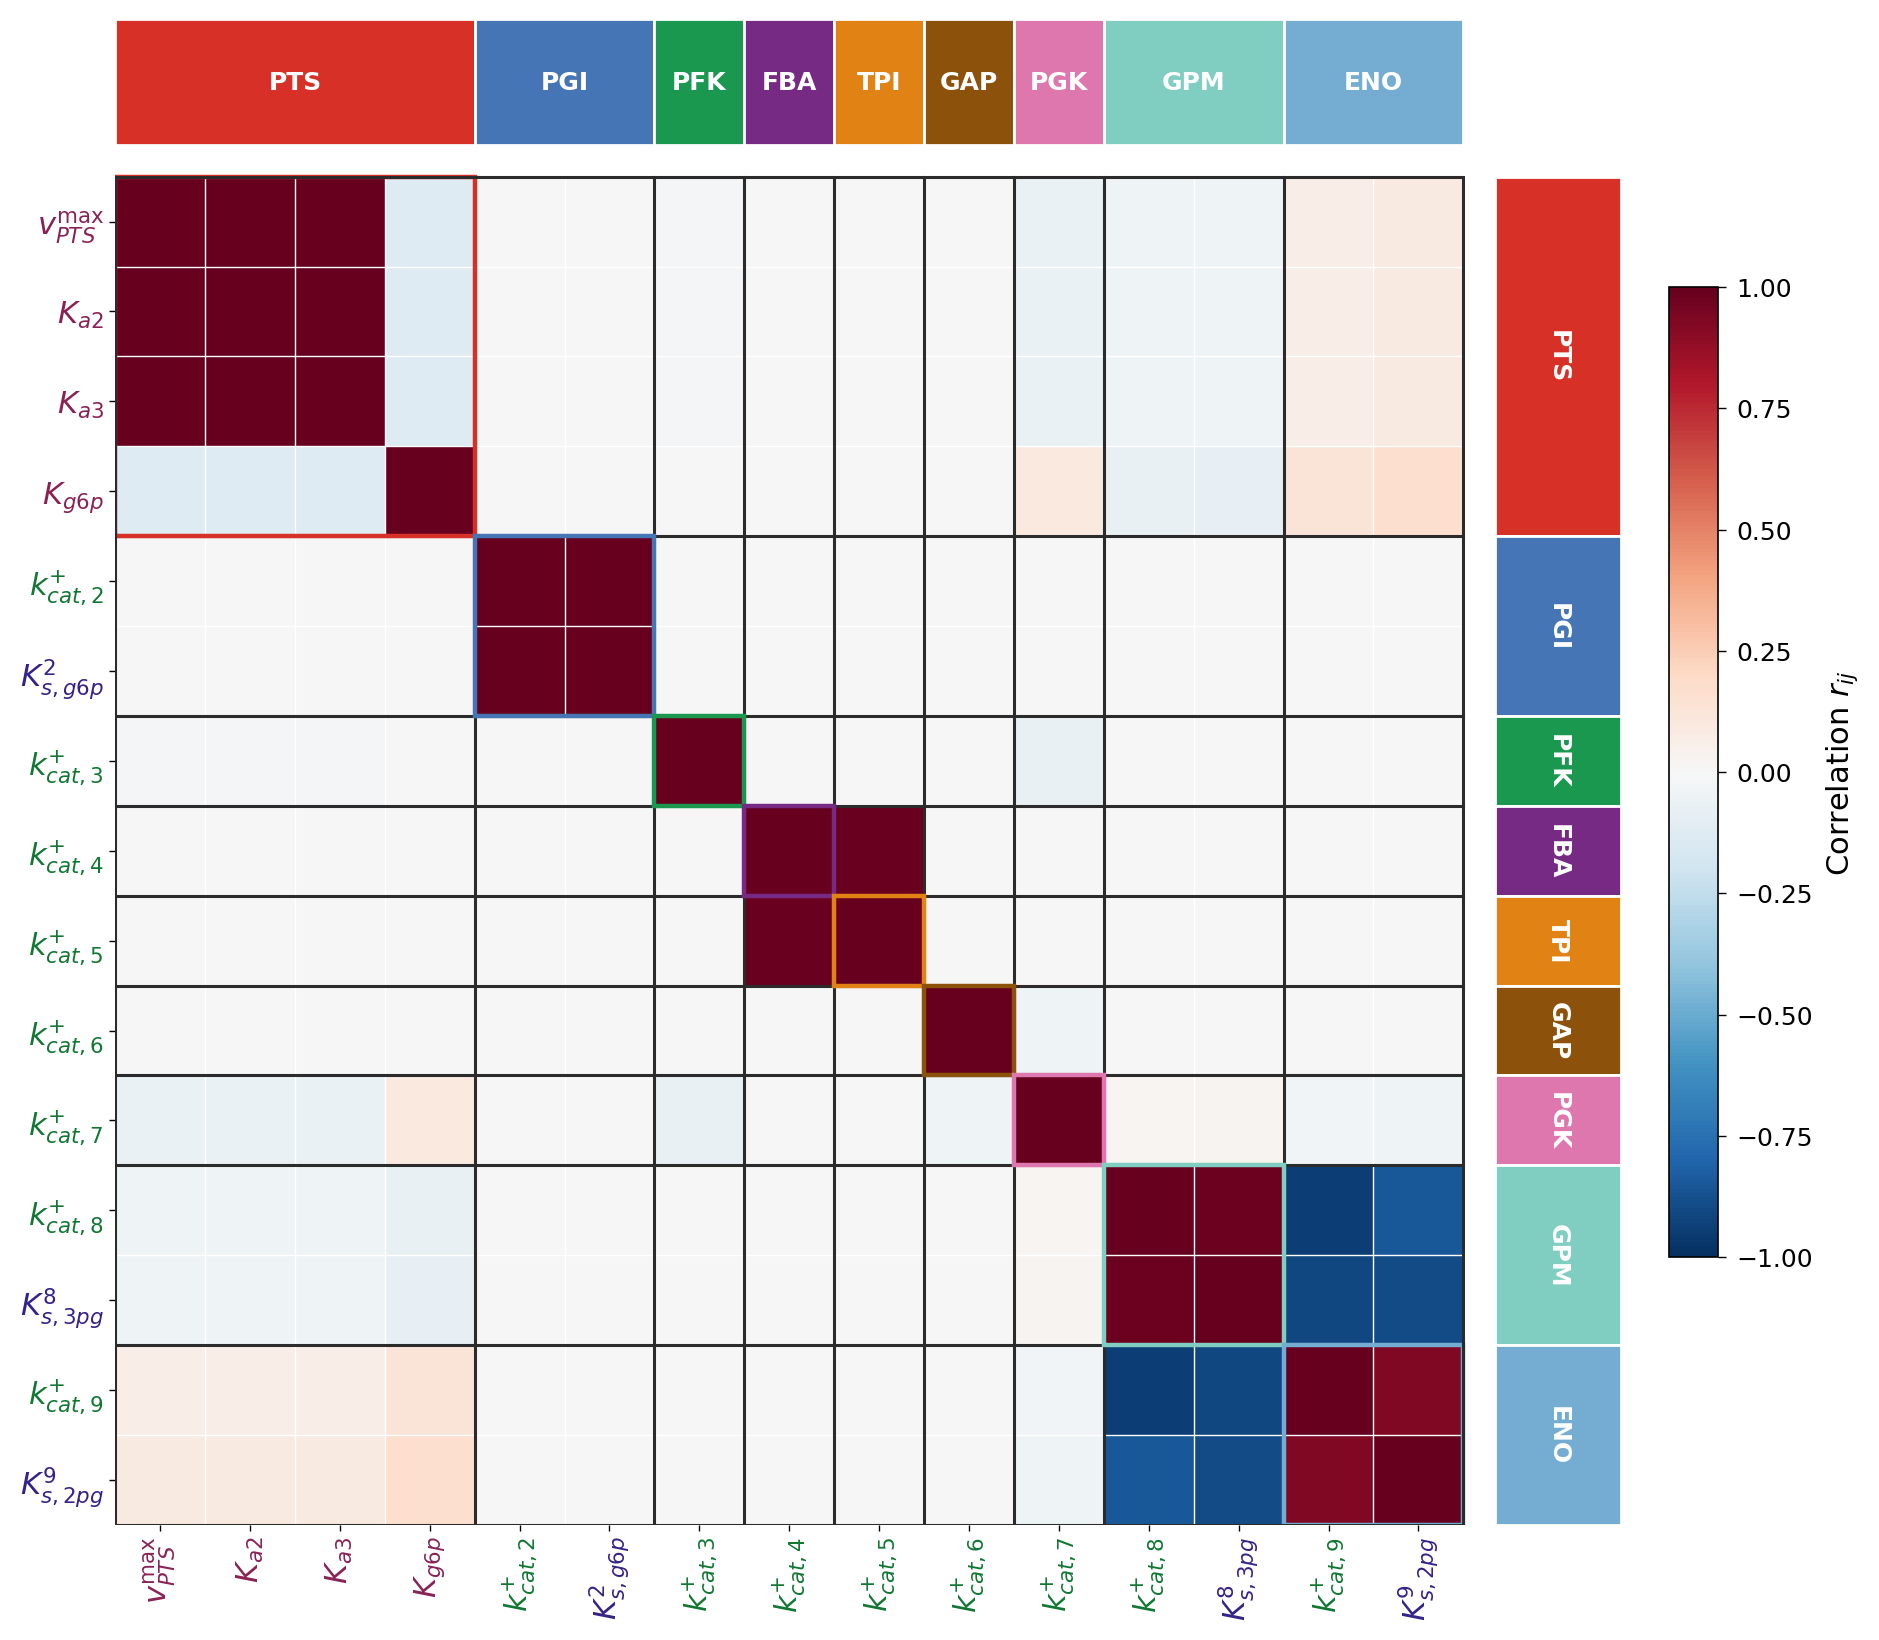

Saved: corr_not_masked.pdf


In [6]:
# Correlation heatmap, unmasked (diagonal -> NaN)
# corr_df covers only free params; _perm gives their display order within that subset.
# Map _perm (indices into param_cols, the all-37 list) to row/col positions in corr_df.
_free_col_to_pos = {col: j for j, col in enumerate(corr_df.columns)}
_perm_in_free = [_free_col_to_pos[param_cols[i]] for i in _perm]
corr_p = corr_df.values[np.ix_(_perm_in_free, _perm_in_free)].copy().astype(float)

styled_matrix_heatmap(
    corr_p, -1, 1,
    r'Correlation $r_{ij}$',
    FIG_DIR / 'corr_not_masked.pdf'
)
print('Saved: corr_not_masked.pdf')

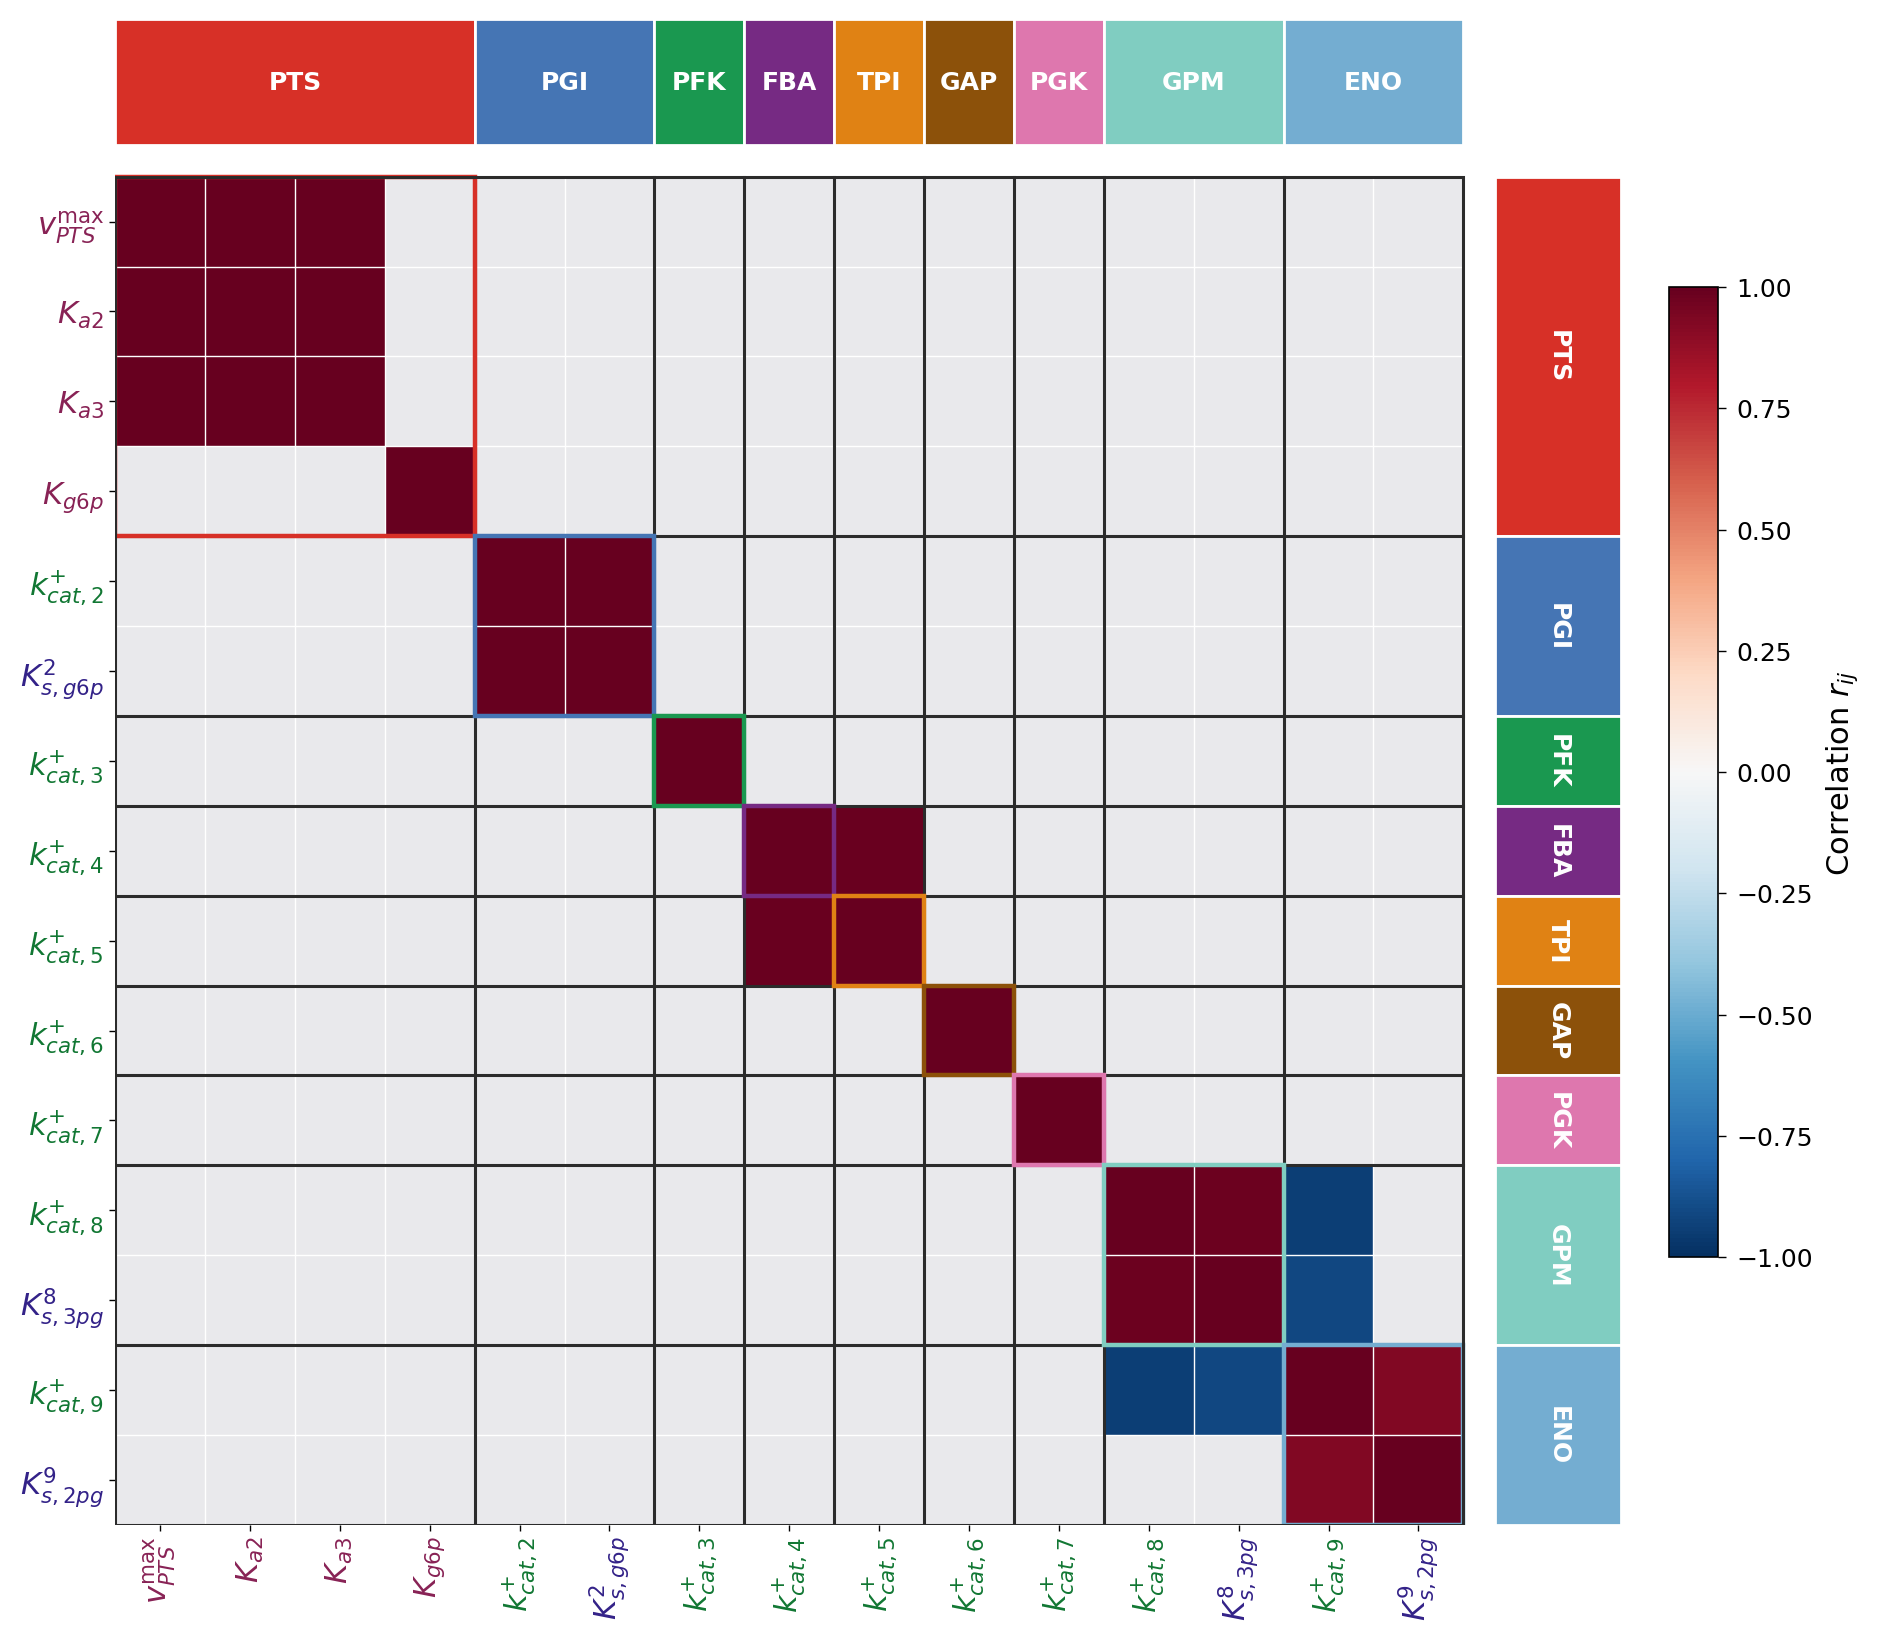

Saved: corr_masked.pdf


In [7]:
# Correlation heatmap, masked: show only |r| >= 0.9 (diagonal -> NaN)
_free_col_to_pos = {col: j for j, col in enumerate(corr_df.columns)}
_perm_in_free = [_free_col_to_pos[param_cols[i]] for i in _perm]
corr_p_full = corr_df.values[np.ix_(_perm_in_free, _perm_in_free)].copy().astype(float)
corr_masked = np.where(np.abs(corr_p_full) >= 0.90, corr_p_full, np.nan)

styled_matrix_heatmap(
    corr_masked, -1, 1,
    r'Correlation $r_{ij}$',
    FIG_DIR / 'corr_masked.pdf',
    annotate=False, annot_fs=5.0
)
print('Saved: corr_masked.pdf')

# Confidence intervals: constrained vs. unconstrained ($\hat{\theta}\pm2\sigma$)

Per-parameter normalized confidence intervals split by identifiability.
**Panel 1** (green, 6 params): identifiable parameters whose CI excludes zero --
data-constrained, meaningful fitted values.
**Panel 2** (red, 31 params): non-identifiable parameters whose CI crosses zero --
sign undetermined by the data; fixed at literature values downstream.

Both panels show $(\hat{\theta}\pm2\sigma)/\hat{\theta}$: estimate sits at 1.0,
bar half-width $= 2\sigma/|\hat{\theta}|$. A bar reaching below $y=0$ confirms the
parameter is unconstrained. Panel 1 uses a linear y-axis; Panel 2 uses symlog
(linthresh=1.0) because the unconstrained half-widths span many orders of magnitude.

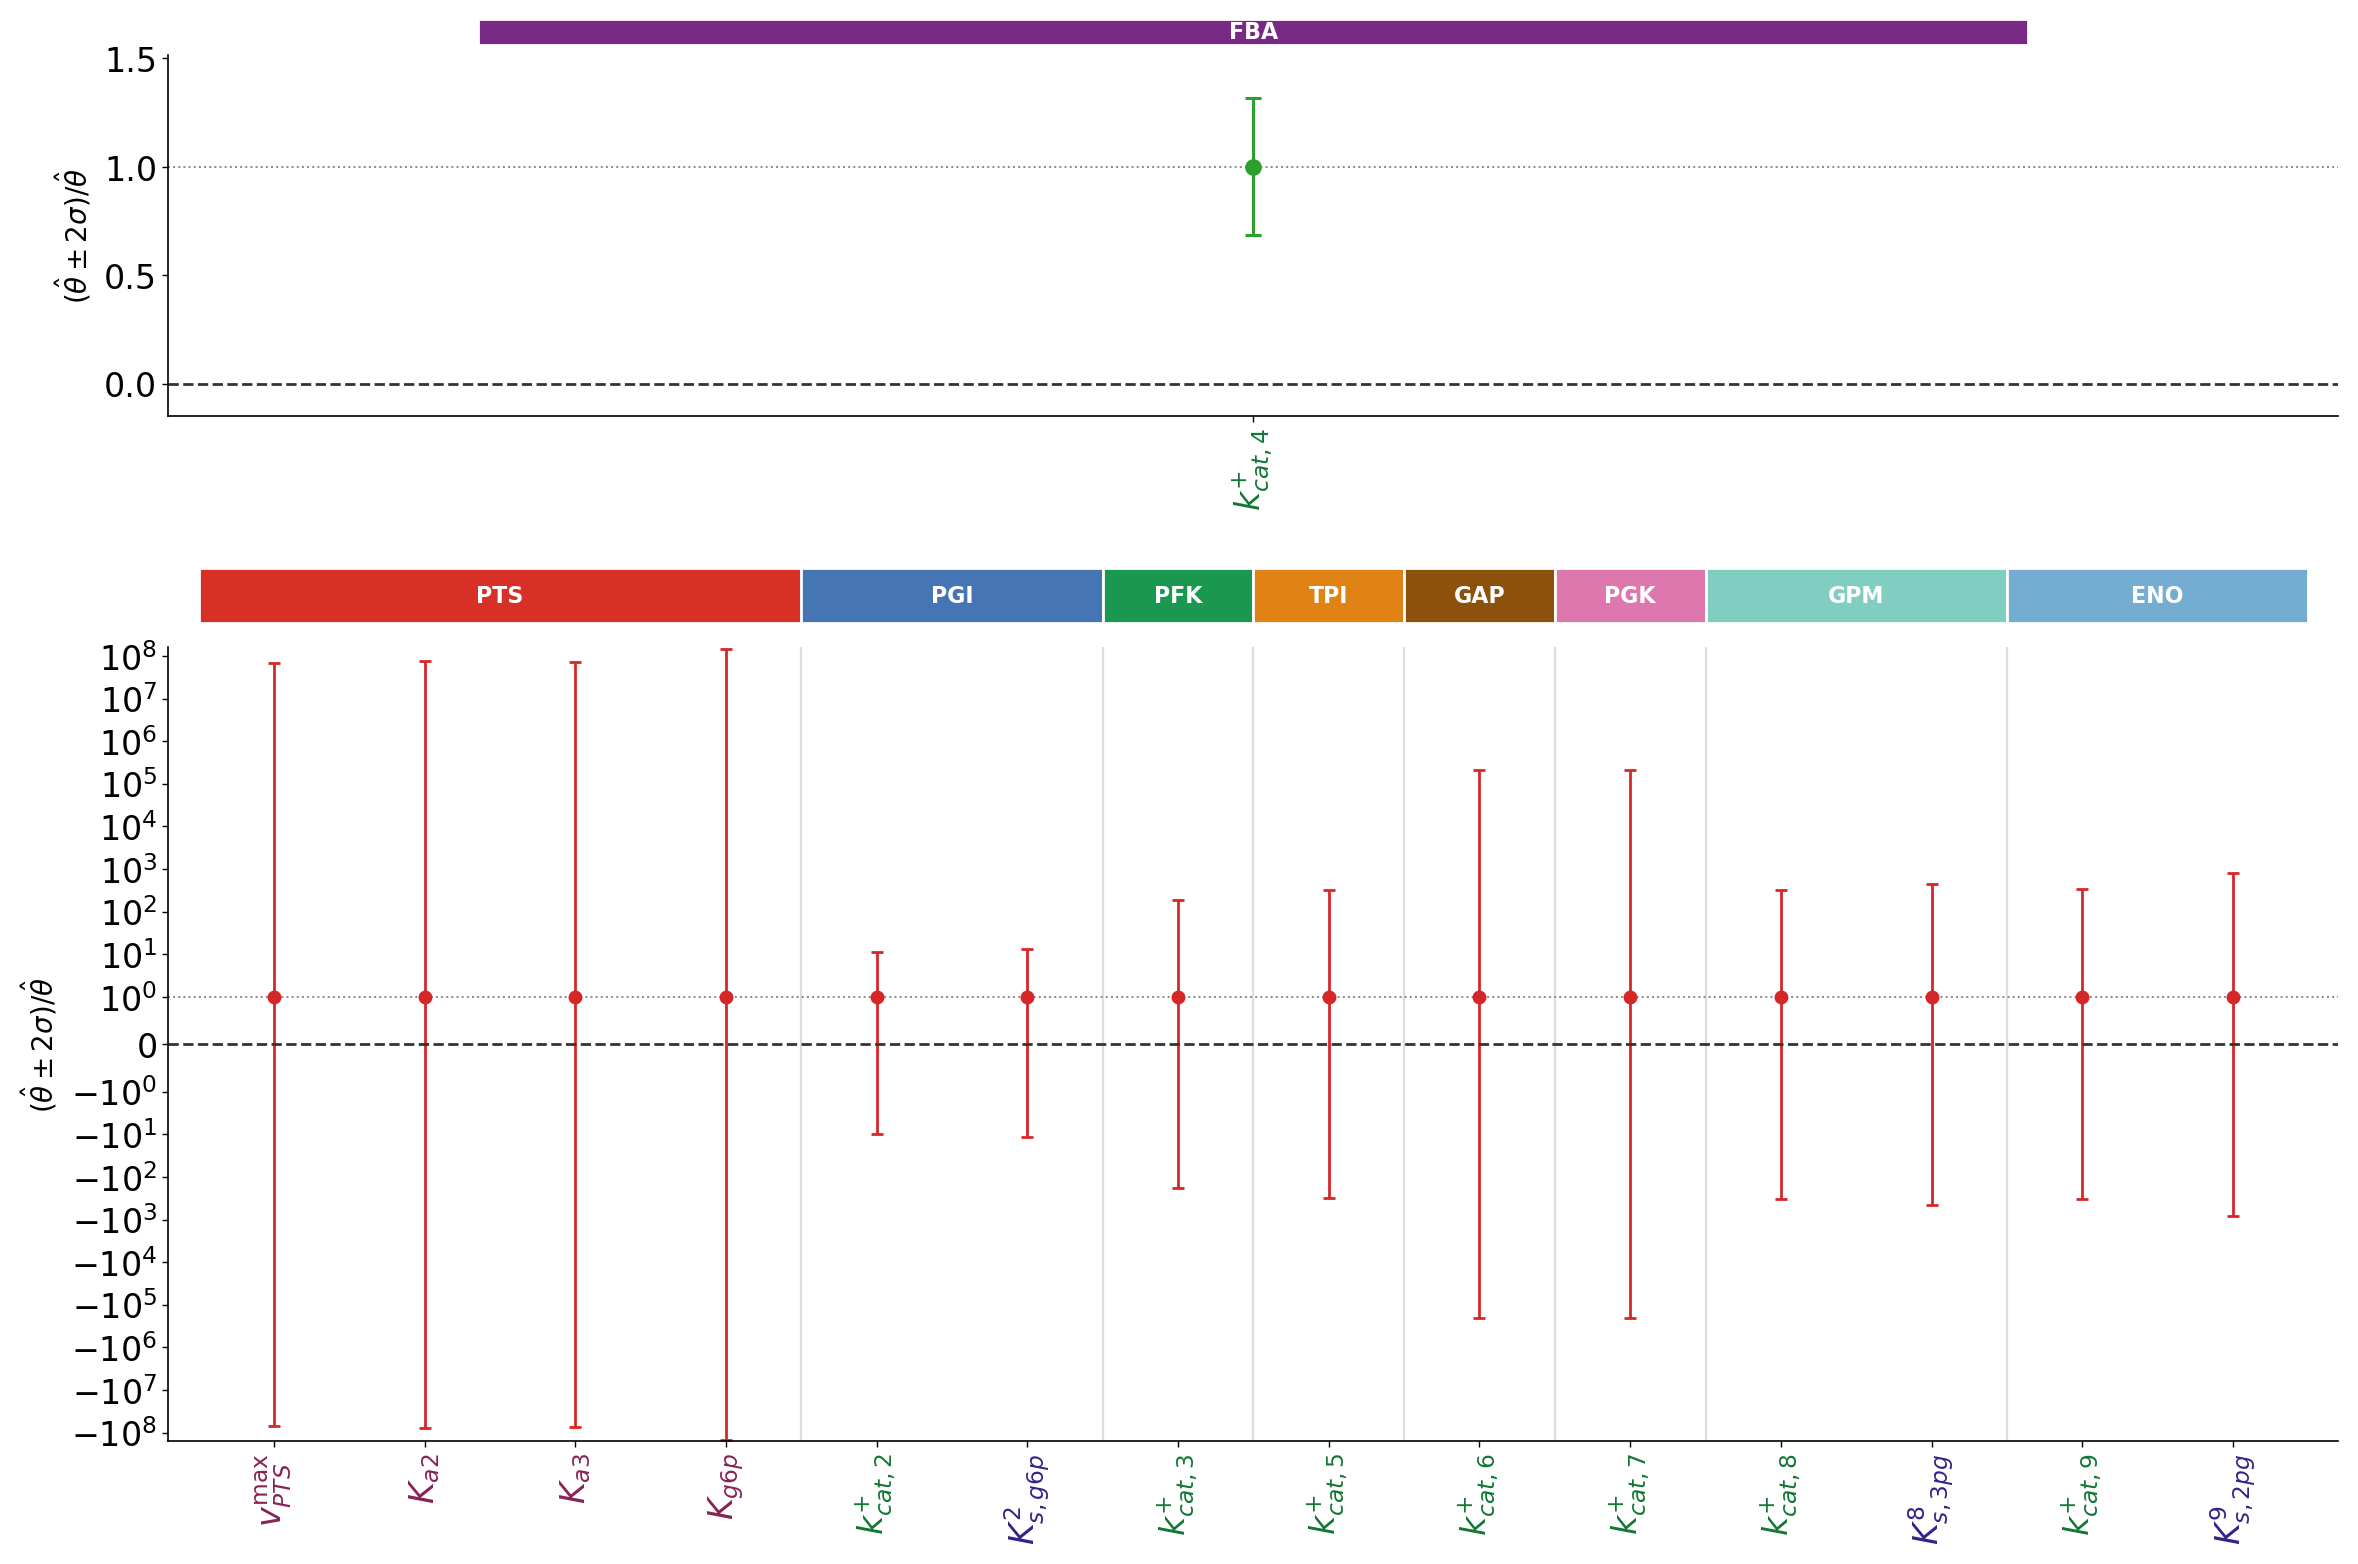

Saved: theta_ci_split.pdf
Panel 1 (constrained): 1 params; Panel 2 (unconstrained): 14 params
14/15 free parameters have a CI that crosses zero.


In [8]:
# Confidence-interval split plot: constrained vs. unconstrained free parameters.
# For fourth estimation, CI covers only free params -- no separate identifiable-subset CSV.
from matplotlib.lines import Line2D

_free_col_to_pos = {col: j for j, col in enumerate(PARAMS)}
_perm_in_free = [_free_col_to_pos[param_cols[i]] for i in _perm]
order = _perm_in_free
names_ord = [PARAMS[i] for i in order]

theta = ci_df['theta'].iloc[order].to_numpy(dtype=float).copy()
sd = ci_df['std_err'].iloc[order].to_numpy(dtype=float).copy()

K_SIGMA = 2
cross_mask = (theta - K_SIGMA * sd) <= 0
half = K_SIGMA * sd / np.abs(theta)

pos1 = np.where(~cross_mask)[0]
pos2 = np.where(cross_mask)[0]

COLOR_NOCROSS = '#2ca02c'
COLOR_CROSS = '#d62728'

def _draw_rxn_strip_and_seps(ax, pos_subset):
    local_of = {p: k for k, p in enumerate(pos_subset)}
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    STRIP_Y, STRIP_H, STRIP_FS = 1.03, 0.07, 8
    # Build seen_rxns for free-param subset
    seen_rxns = {}
    for p_pos in pos_subset:
        orig_i = _perm[p_pos]
        for name, i_s, i_e, col in reaction_groups:
            if i_s <= orig_i <= i_e:
                k = local_of[p_pos]
                if name not in seen_rxns:
                    seen_rxns[name] = [k, k, col]
                else:
                    seen_rxns[name][1] = max(seen_rxns[name][1], k)
    for name, (k0, k1, col) in seen_rxns.items():
        if k0 > 0:
            ax.axvline(k0 - 0.5, color='#dddddd', lw=0.8, zorder=0)
        ax.add_patch(MplRect((k0 - 0.5, STRIP_Y), k1 - k0 + 1, STRIP_H,
                             transform=trans, facecolor=col, edgecolor='white',
                             lw=1.0, clip_on=False, zorder=4))
        ax.text((k0 + k1) / 2, STRIP_Y + STRIP_H / 2, name, transform=trans,
                ha='center', va='center', fontsize=STRIP_FS, fontweight='bold',
                color='white', clip_on=False, zorder=5)

mpl.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 12,
    'axes.linewidth': 0.6, 'mathtext.fontset': 'dejavusans',
})

fig = plt.figure(figsize=(14.0, 9.0), dpi=200)
gs = fig.add_gridspec(2, 1, height_ratios=[1, 2.2], hspace=0.4)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

x1 = np.arange(len(pos1))
for k, p in enumerate(pos1):
    ax1.errorbar(k, 1.0, yerr=half[p], fmt='o', color=COLOR_NOCROSS,
                 markerfacecolor=COLOR_NOCROSS, markeredgecolor=COLOR_NOCROSS,
                 markersize=5, capsize=3, elinewidth=1.1, capthick=1.1)
ax1.axhline(1.0, color='#888888', lw=0.7, ls=':')
ax1.axhline(0.0, color='#333333', lw=1.0, ls='--')
ax1.set_ylim(-0.15, max(float((1.0 + half[pos1]).max()) * 1.15, 1.3) if len(pos1) else 1.3)
ax1.set_xticks(x1)
ticks1 = ax1.set_xticklabels([param_labels_p[p] for p in pos1], rotation=90, fontsize=12, ha='center')
for t, p in zip(ticks1, pos1):
    t.set_color(_type_color(p))
    t.set_fontweight('semibold')
ax1.set_xlim(-0.7, len(x1) - 0.3)
ax1.set_ylabel(r'$(\hat{\theta} \pm 2\sigma)/\hat{\theta}$', fontsize=10)
ax1.tick_params(length=2, width=0.5, pad=2)
for s in ('top', 'right'):
    ax1.spines[s].set_visible(False)
_draw_rxn_strip_and_seps(ax1, pos1)

x2 = np.arange(len(pos2))
for k, p in enumerate(pos2):
    ax2.errorbar(k, 1.0, yerr=half[p], fmt='o', color=COLOR_CROSS,
                 markerfacecolor=COLOR_CROSS, markeredgecolor=COLOR_CROSS,
                 markersize=4, capsize=2, elinewidth=1.0, capthick=1.0)
ax2.axhline(1.0, color='#888888', lw=0.7, ls=':')
ax2.axhline(0.0, color='#333333', lw=1.0, ls='--')
ax2.set_yscale('symlog', linthresh=1.0)
ax2.set_xticks(x2)
ticks2 = ax2.set_xticklabels([param_labels_p[p] for p in pos2], rotation=90, fontsize=12, ha='center')
for t, p in zip(ticks2, pos2):
    t.set_color(_type_color(p))
    t.set_fontweight('semibold')
ax2.set_xlim(-0.7, len(x2) - 0.3)
ax2.set_ylabel(r'$(\hat{\theta} \pm 2\sigma)/\hat{\theta}$', fontsize=10)
ax2.tick_params(length=2, width=0.5, pad=2)
for s in ('top', 'right'):
    ax2.spines[s].set_visible(False)
_draw_rxn_strip_and_seps(ax2, pos2)

fig.savefig(FIG_DIR / 'theta_ci_split.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIG_DIR / 'theta_ci_split.jpg', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()
mpl.rcParams.update(mpl.rcParamsDefault)

n_cross = int(cross_mask.sum())
print('Saved: theta_ci_split.pdf')
print(f'Panel 1 (constrained): {len(pos1)} params; Panel 2 (unconstrained): {len(pos2)} params')
print(f'{n_cross}/{len(order)} free parameters have a CI that crosses zero.')

# report

In [9]:
# Correlated-pairs LaTeX table: pairs with |r| >= 0.9 among free params.
all_params_orig = list(corr_df.columns)
param_latex = {k: _param_labels_orig[_perm[j]] for j, k in enumerate(all_params_orig)}

pairs = []
n_params = len(all_params_orig)
corr_vals = corr_df.values

for i in range(n_params):
    for j in range(i + 1, n_params):
        r = corr_vals[i, j]
        if np.isfinite(r) and abs(r) >= 0.9:
            pairs.append({
                'param_i': param_latex[all_params_orig[i]],
                'param_j': param_latex[all_params_orig[j]],
                'r': round(r, 4)
            })

pairs_df = pd.DataFrame(pairs, columns=['param_i', 'param_j', 'r'])
pairs_df = pairs_df.sort_values('r', key=abs, ascending=False).reset_index(drop=True)

print(f'Number of correlated pairs (|r| >= 0.9) over free params: {len(pairs_df)}')
if len(pairs_df):
    print(pairs_df.to_latex(index=False))

Number of correlated pairs (|r| >= 0.9) over free params: 9
\begin{tabular}{llr}
\toprule
param_i & param_j & r \\
\midrule
$v^{\max}_{PTS}$ & $K_{a3}$ & 1.000000 \\
$v^{\max}_{PTS}$ & $K_{a2}$ & 0.999900 \\
$K_{a2}$ & $K_{a3}$ & 0.999900 \\
$k^{+}_{cat,2}$ & $K_{s,g6p}^{2}$ & 0.997100 \\
$k^{+}_{cat,4}$ & $k^{+}_{cat,5}$ & 0.985600 \\
$k^{+}_{cat,8}$ & $K_{s,3pg}^{8}$ & 0.976700 \\
$k^{+}_{cat,8}$ & $k^{+}_{cat,9}$ & -0.939800 \\
$k^{+}_{cat,9}$ & $K_{s,2pg}^{9}$ & 0.924500 \\
$K_{s,3pg}^{8}$ & $k^{+}_{cat,9}$ & -0.913400 \\
\bottomrule
\end{tabular}



In [10]:
# Fix-justification table for fourth estimation free params.
# Uses the full free-param covariance; params with CI crossing zero are candidates
# for fixing in a further reduction step.
fix_tbl = ci_df[['theta', 'std_err', 'ci_low', 'ci_high', 'cv_percent']].copy()
fix_tbl['variance'] = np.diag(cov_df.to_numpy())
fix_tbl['ci_crosses_zero'] = (fix_tbl['ci_low'] <= 0) & (fix_tbl['ci_high'] >= 0)
fix_tbl = fix_tbl.sort_values('cv_percent', ascending=False)
fix_tbl.index.name = 'param_free'

out = RESULTS_DIR / 'fix_justification.csv'
fix_tbl.to_csv(out)
n_cross = int(fix_tbl['ci_crosses_zero'].sum())
print(f'Saved: {out}  ({len(fix_tbl)} free parameters)')
print(f'{n_cross}/{len(fix_tbl)} have a 95% CI that crosses zero.')
print()
print(fix_tbl.round(3).to_string())

Saved: results/fourth_estimation/fix_justification.csv  (15 free parameters)
14/15 have a 95% CI that crosses zero.

               theta       std_err        ci_low       ci_high    cv_percent      variance  ci_crosses_zero
param_free                                                                                                 
K_g6p_1       10.696  7.754393e+08 -1.519861e+09  1.519861e+09  7.249962e+09  6.013062e+17             True
Ka2_1          0.060  2.278925e+06 -4.466693e+06  4.466694e+06  3.774999e+09  5.193500e+12             True
Ka3_1          5.190  1.916935e+08 -3.757192e+08  3.757192e+08  3.693425e+09  3.674638e+16             True
v_max_1       74.299  2.577694e+09 -5.052280e+09  5.052280e+09  3.469357e+09  6.644505e+18             True
kcat_f_7     980.632  1.025638e+08 -2.010240e+08  2.010259e+08  1.045894e+07  1.051932e+16             True
kcat_f_6      15.528  1.610996e+06 -3.157537e+06  3.157568e+06  1.037496e+07  2.595308e+12             True
Ks_2pg_9       0.01

## Structural identifiability: SVD of the free-parameter ROSM (Stigter & Molenaar, 2015)

Complements the correlation/CV-based `fix_justification` above with a Fast Structural
Identifiability Analysis (FSIA) check: build the Relative Output Sensitivity Matrix
(ROSM) restricted to the 15 free parameters and the *measured* outputs only (unmeasured
outputs are excluded so they do not overstate identifiability), stack it across all 22
conditions, and take its SVD. A near-zero singular value means the corresponding
right-singular-vector direction (a combination of free parameters) is not determinable
from this data. We inspect only the SMALLEST singular value's direction below --
compare its sigma_min and the ROSM condition number against the third estimation's
(sigma_min = 1.45e-3, cond = 2.8e4) to see whether fixing Ks_fbp_4 actually improved
identifiability or just shifted the same near-collinearity elsewhere.

In [11]:
# ROSM restricted to free params + measured outputs only (unmeasured outputs would
# overstate identifiability). MEASURED_KEYS mirrors the measurement_error dict built
# by src/utils.py::build_analysis_model (shared with fixed_estimation.ipynb) -- NOT
# a plain notna() check on real.csv, since a few outputs (e.g. C_dhap) have sparse
# ground-truth values in only a handful of conditions but are excluded from the
# actual fit's weighting because coverage is too thin to assign a noise level.
MEASURED_KEYS = ['C_g6p', 'C_f6p', 'C_fbp', 'C_3pg', 'C_pep',
                 'v_pts', 'v_pgi', 'v_pfkB', 'v_fbaA', 'v_tpiA', 'v_gapA', 'v_pgk', 'v_gpmA', 'v_eno']
measured_mask = np.array([n in MEASURED_KEYS for n in row_name])
print('Measured outputs: %d/%d %s' % (int(measured_mask.sum()), len(row_name),
      [n for n, m in zip(row_name, measured_mask) if m]))

rosm = rel_stack[:, measured_mask, :][:, :, _perm].reshape(-1, len(_perm))
finite_rows = np.all(np.isfinite(rosm), axis=1)
rosm = rosm[finite_rows]
print('ROSM shape (measured rows x free params): %s' % (rosm.shape,))

U_svd, S_svd, Vh_svd = np.linalg.svd(rosm, full_matrices=False)
print('Singular values:', np.array2string(S_svd, precision=3))
print('sigma_max = %.3e, sigma_min = %.3e, cond = %.3e' % (S_svd[0], S_svd[-1], S_svd[0] / S_svd[-1]))

Measured outputs: 14/18 ['C_g6p', 'C_f6p', 'C_fbp', 'C_3pg', 'C_pep', 'v_pts', 'v_pgi', 'v_pfkB', 'v_fbaA', 'v_tpiA', 'v_gapA', 'v_pgk', 'v_gpmA', 'v_eno']
ROSM shape (measured rows x free params): (306, 15)
Singular values: [8.353e+01 3.957e+01 2.286e+01 7.732e+00 1.407e+00 1.099e+00 8.071e-01
 7.295e-01 2.487e-01 8.527e-02 6.065e-02 3.708e-02 1.950e-02 4.785e-03
 2.465e-03]
sigma_max = 8.353e+01, sigma_min = 2.465e-03, cond = 3.388e+04


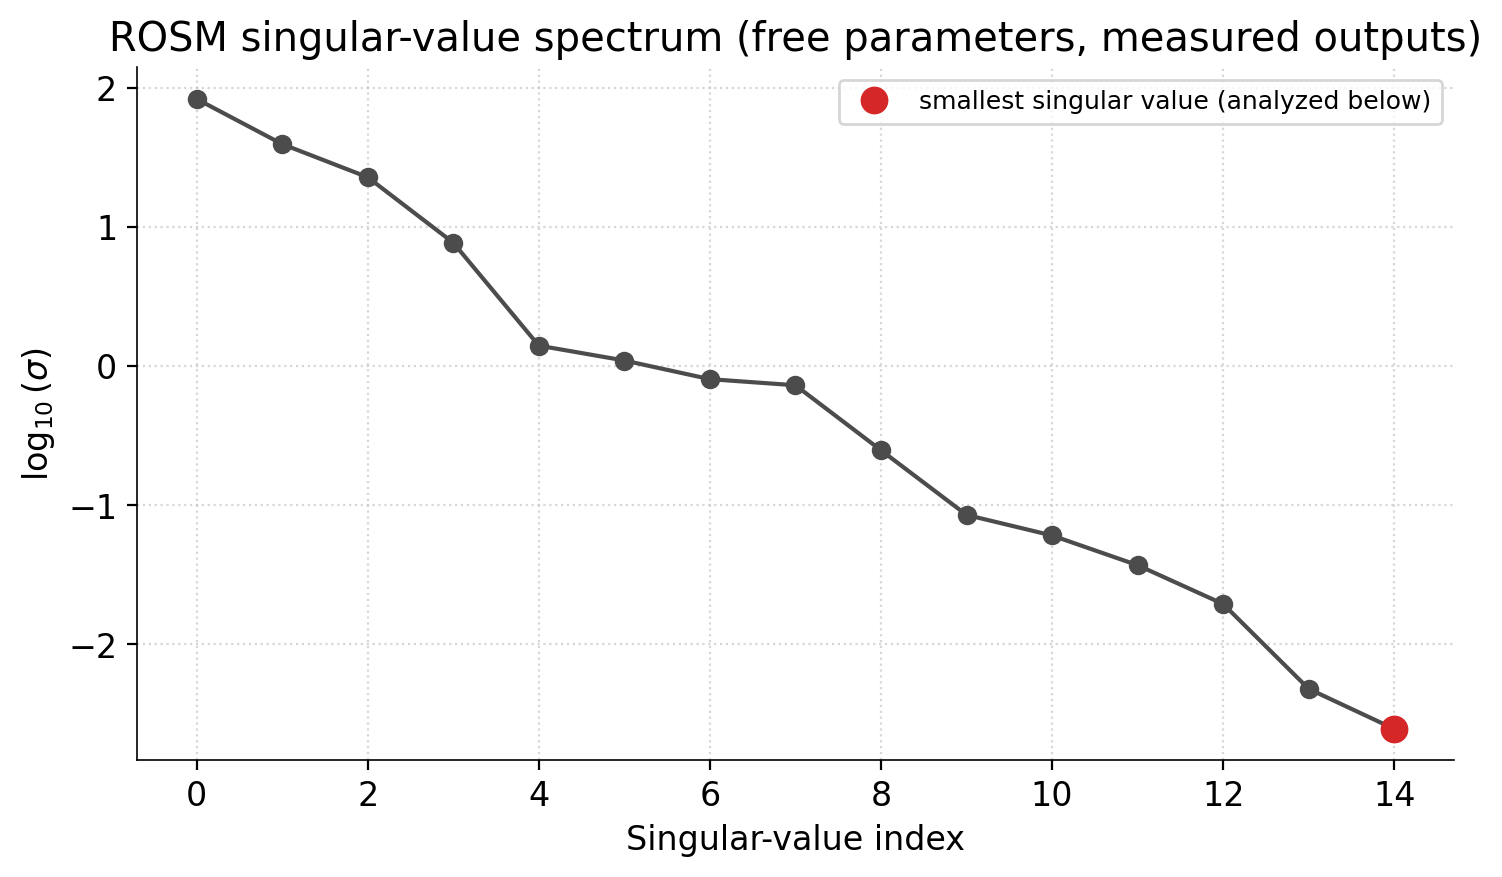

In [12]:
# Spectrum styled like the other plots in this notebook (shared rcParams block,
# top/right spines removed); the smallest value (analyzed below) is highlighted
# in the same red used for "crosses zero / unconstrained" in the CI plot above.
mpl.rcParams.update({
    'font.family':     'sans-serif',
    'font.size':        12,
    'axes.linewidth':   0.6,
    'mathtext.fontset': 'dejavusans',
})

fig, ax = plt.subplots(figsize=(8.5, 4.5), dpi=200)
ax.plot(np.arange(len(S_svd)), np.log10(S_svd), 'o-', color='#4c4c4c',
        markersize=6, markerfacecolor='#4c4c4c', zorder=2)
ax.plot(len(S_svd) - 1, np.log10(S_svd[-1]), 'o', color='#d62728', markersize=9,
        zorder=3, label='smallest singular value (analyzed below)')
ax.set_xlabel('Singular-value index')
ax.set_ylabel(r'$\log_{10}(\sigma)$')
ax.set_title('ROSM singular-value spectrum (free parameters, measured outputs)')
ax.grid(True, ls=':', alpha=0.5)
ax.legend(loc='upper right', fontsize=9, frameon=True)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)

fig.savefig(FIG_DIR / 'rosm_singular_spectrum.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIG_DIR / 'rosm_singular_spectrum.jpg', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()
mpl.rcParams.update(mpl.rcParamsDefault)

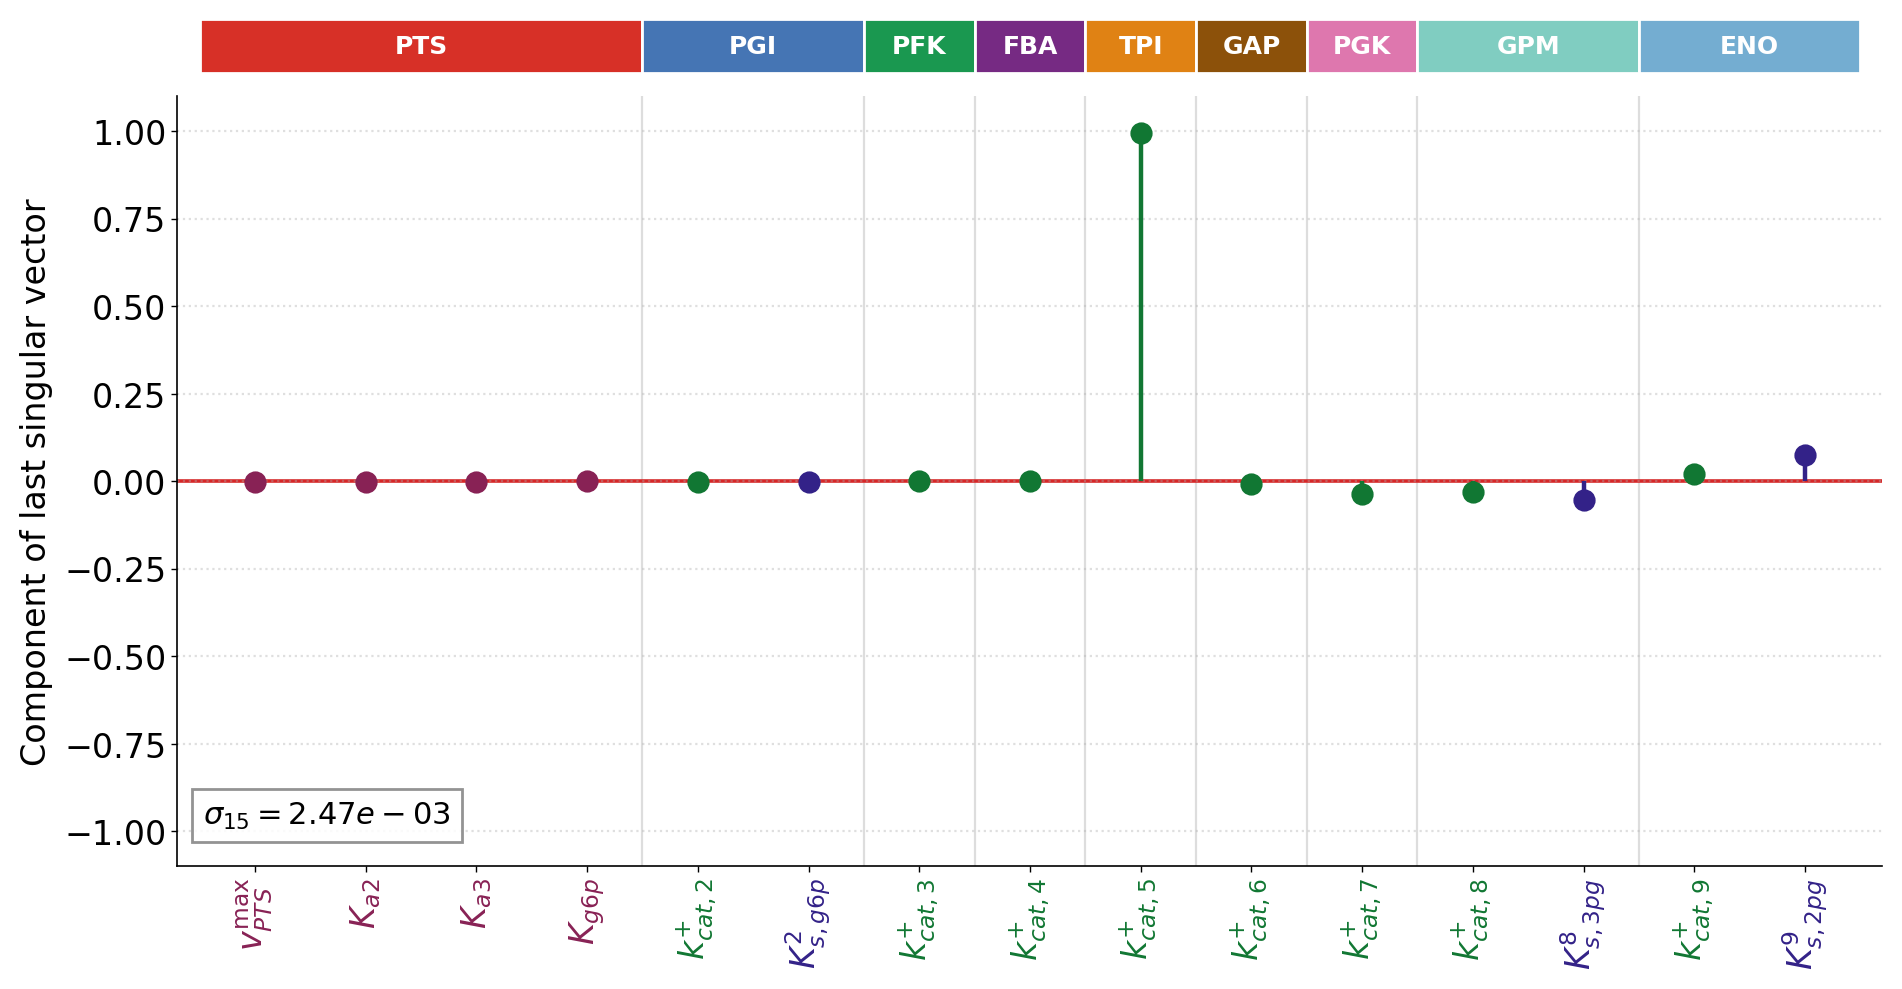

Dominant parameters in the smallest-singular-value direction (sigma_15 = 2.465e-03):
  kcat_f_5        v = +0.994
  Ks_2pg_9        v = +0.076
  Ks_3pg_8        v = -0.054
  kcat_f_7        v = -0.035


In [13]:
# Only the smallest singular value's right singular vector is shown: it is the
# single most informative diagnostic for "what to fix next" -- its dominant
# components are the free-parameter combination least constrained by the data.
# Styled to match the correlation/sensitivity/CI plots above: shared rcParams
# block, type-colored stems + x-tick labels (via _type_color), reaction-group
# strip on top (same construction as the CI split plot's _draw_rxn_strip_and_seps).
# No on-axes title, matching those plots -- the reaction strip + markdown header
# above carry the context instead.
mpl.rcParams.update({
    'font.family':     'sans-serif',
    'font.size':        12,
    'axes.linewidth':   0.6,
    'mathtext.fontset': 'dejavusans',
})

_ZERO_LINE_COLOR = '#d62728'
sigma_min = S_svd[-1]
v_min = Vh_svd[-1]
xv = np.arange(len(_perm))

fig, ax = plt.subplots(figsize=(11.0, 5.0), dpi=200)

ax.axhline(0.0, color=_ZERO_LINE_COLOR, lw=1.3, zorder=1)
for i in range(len(xv)):
    c = _type_color(i)
    ax.vlines(xv[i], 0.0, v_min[i], color=c, linewidth=1.6, zorder=2)
    ax.plot(xv[i], v_min[i], 'o', color=c, markersize=7, zorder=3)

ax.set_xlim(-0.7, len(xv) - 0.3)
ax.set_ylim(-1.1, 1.1)
ax.set_xticks(xv)
ticks = ax.set_xticklabels(param_labels_p, rotation=90, fontsize=12, ha='center')
for i, t in enumerate(ticks):
    t.set_color(_type_color(i))
    t.set_fontweight('semibold')
ax.tick_params(length=2, width=0.5, pad=2)
ax.set_ylabel('Component of last singular vector')
ax.grid(True, axis='y', ls=':', alpha=0.4)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)

ax.text(0.015, 0.055, r'$\sigma_{%d} = %.2e$' % (len(S_svd), sigma_min), transform=ax.transAxes,
        fontsize=11, bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85))

seen_rxns = {}
for p_pos, orig_i in enumerate(_perm):
    for name, i_s, i_e, col in reaction_groups:
        if i_s <= orig_i <= i_e:
            if name not in seen_rxns:
                seen_rxns[name] = [p_pos, p_pos, col]
            else:
                seen_rxns[name][1] = p_pos

trans = blended_transform_factory(ax.transData, ax.transAxes)
STRIP_Y, STRIP_H, STRIP_FS = 1.03, 0.07, 9
for name, (k0, k1, col) in seen_rxns.items():
    if k0 > 0:
        ax.axvline(k0 - 0.5, color='#dddddd', lw=0.8, zorder=0)
    ax.add_patch(MplRect((k0 - 0.5, STRIP_Y), k1 - k0 + 1, STRIP_H,
                         transform=trans, facecolor=col, edgecolor='white',
                         lw=1.0, clip_on=False, zorder=4))
    ax.text((k0 + k1) / 2, STRIP_Y + STRIP_H / 2, name, transform=trans,
            ha='center', va='center', fontsize=STRIP_FS, fontweight='bold',
            color='white', clip_on=False, zorder=5)

fig.savefig(FIG_DIR / 'rosm_nullspace_min.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIG_DIR / 'rosm_nullspace_min.jpg', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()
mpl.rcParams.update(mpl.rcParamsDefault)

free_names_ordered = [param_cols[i] for i in _perm]
order = np.argsort(-np.abs(v_min))
print('Dominant parameters in the smallest-singular-value direction (sigma_%d = %.3e):' % (len(S_svd), sigma_min))
for i in order[:4]:
    print('  %-14s  v = %+.3f' % (free_names_ordered[i], v_min[i]))

## Model performance: predicted vs measured (metabolites and fluxes on separate color scales)

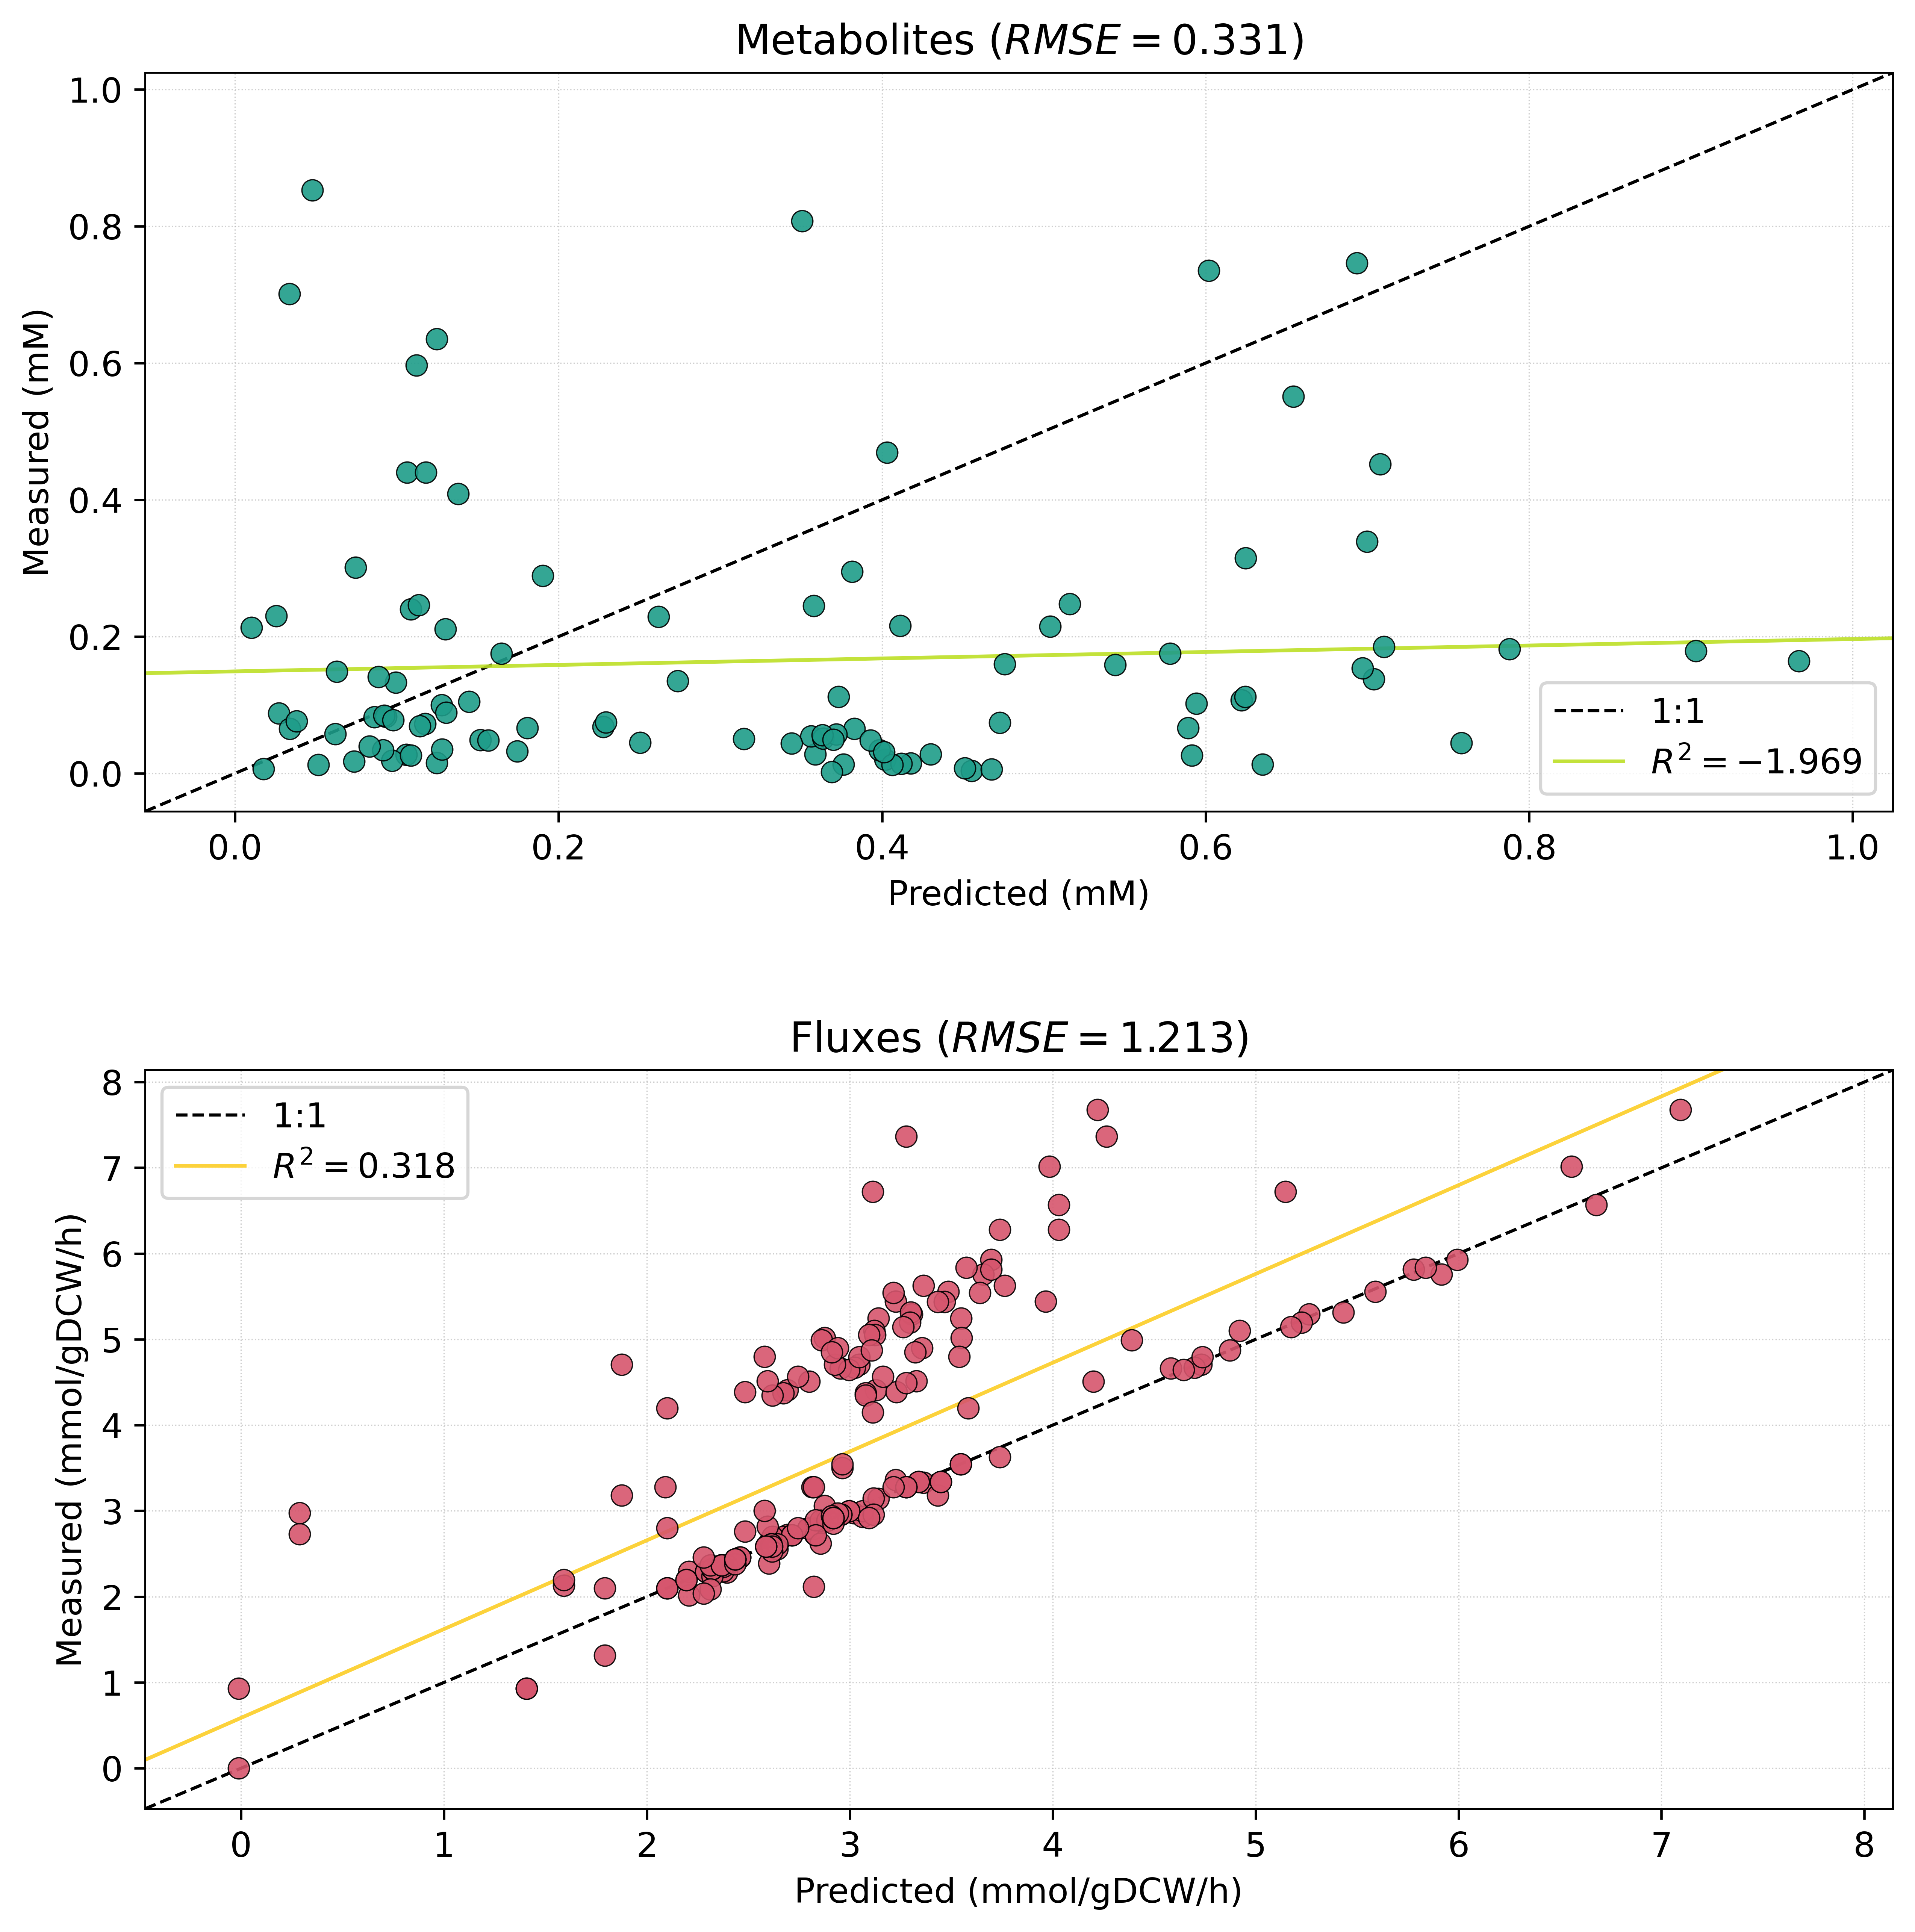

Saved: ['parity_fourth_metabolites.pdf', 'parity_fourth_fluxes.pdf']


In [14]:
# Model performance: predicted vs measured. Metabolites and fluxes get SEPARATE
# figures (very different scales). One solid color per group; no per-condition
# coloring. Reads only the saved CSVs -- no re-run of the estimation needed.
from scipy.stats import linregress
from sklearn.metrics import r2_score, root_mean_squared_error

real_df = pd.read_csv(RESULTS_DIR / 'real.csv', index_col=0)
pred_df = pd.read_csv(RESULTS_DIR / 'predictions_fitted.csv', index_col=0)

# ---- edit me -------------------------------------------------------------
# one entry per output group: (col prefix, label, colormap, log axes?, units, outfile)
GROUPS = [
    ('C_', 'Metabolites', 'viridis', False, '(mM)',          FIG_DIR / 'parity_fourth_metabolites.pdf'),
    ('v_', 'Fluxes',      'plasma',  False, '(mmol/gDCW/h)', FIG_DIR / 'parity_fourth_fluxes.pdf'),
]
MARKER_SIZE = 46
# --------------------------------------------------------------------------

# Match the font styling used by the other plots in this notebook.
_rc_save = {k: mpl.rcParams[k] for k in (
    'font.family', 'font.size', 'axes.linewidth', 'mathtext.fontset')}
mpl.rcParams.update({
    'font.family':     'sans-serif',
    'font.size':        11,
    'axes.linewidth':   0.6,
    'mathtext.fontset': 'dejavusans',
})

conds = [c for c in real_df.index if c in pred_df.index]
fig, ax = plt.subplots(2, 1, figsize=(10,10), dpi=600,
                       gridspec_kw={'hspace': 0.35, 'height_ratios': [1, 1]})

for i, (prefix, label, cmap, logscale, units, outfile) in enumerate(GROUPS):
    group_cols = [c for c in real_df.columns if c.startswith(prefix)]
    xs, ys = [], []
    for cond in conds:
        for col in group_cols:
            rv = real_df.loc[cond, col]
            pv = pred_df.loc[cond, col]
            if np.isfinite(rv) and np.isfinite(pv):
                xs.append(float(pv)); ys.append(float(rv))
    x, y = np.array(xs), np.array(ys)

    if logscale and x.size:
        keep = (x > 0) & (y > 0)          # log axes need positive values
        x, y = x[keep], y[keep]

    colors = plt.get_cmap(cmap)
    ax[i].scatter(x, y, color=colors(0.55), s=MARKER_SIZE, edgecolor='k',
               linewidth=0.4, alpha=0.9, zorder=3)
    lo = min(x.min(), y.min()); hi = max(x.max(), y.max())
    if logscale:
        lo2, hi2 = lo / 1.4, hi * 1.4
        ax[i].set_xscale('log'); ax[i].set_yscale('log')
    else:
        pad = (hi - lo) * 0.06 or 0.1
        lo2, hi2 = lo - pad, hi + pad
    ax[i].plot([lo2, hi2], [lo2, hi2], 'k--', lw=1, zorder=2, label='1:1')
    ax[i].set_xlim(lo2, hi2)
    ax[i].set_ylim(lo2, hi2)
    # ax[i].set_aspect('equal', adjustable='box')

    # Least-squares fit line + R^2 (predicted vs measured).
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2 = r2_score(y, x)
    ax[i].plot([lo2, hi2], [slope * lo2 + intercept, slope * hi2 + intercept],
            lw=1.2, zorder=2, label=r'$R^2=%.3f$' % r2, c=colors(0.9),
            alpha=0.9, linestyle='-')
    rmse     = root_mean_squared_error(x, y)  # RMSE
    ax[i].set_title(label + f' ($RMSE={rmse:.3f}$)')
    ax[i].set_xlabel('Predicted ' + units); ax[i].set_ylabel('Measured ' + units)
    ax[i].grid(True, which='both', ls=':', lw=0.4, alpha=0.6)
    ax[i].legend(loc='best')
# fig.tight_layout()
fig.savefig(outfile, dpi=300, bbox_inches='tight')
fig.savefig(outfile.with_suffix('.jpg'), dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

mpl.rcParams.update(_rc_save)
print('Saved:', [str(g[5].name) for g in GROUPS])
